<a href="https://colab.research.google.com/github/ericyoc/3d_printer_sidechannel_poc/blob/main/3d_printer_sidechannel_poc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Modal Side-Channel Attack and Defense Evaluation on 3D Printers
### Acoustic + Vibration Fusion Against Active Motor Noise Cancellation

**Dataset:** Madamopoulos & Tsoutsos (2024). *3D Printer Audio and Vibration Side Channel Dataset.*  
Zenodo. https://doi.org/10.5281/zenodo.13329934

**Experimental Design:**  
This notebook empirically evaluates four conditions in sequence:

| Phase | Description |
|---|---|
| **Pre-Attack Baseline** | Signal discriminability before any attack model is applied |
| **Post-Attack** | Classification accuracy: Acoustic-only, Vibration-only, Fused |
| **Post-Defense** | Simulated Active Motor Noise Cancellation applied to acoustic channel |
| **Defense Evaluation** | Does fusion defeat the countermeasure? |

**Research Question:** Does multi-modal fusion of acoustic and vibration side-channels defeat Active Motor Noise Cancellation (AMNC) in modern FDM 3D printers?

---
**Setup Instructions:**
1. Download the dataset from https://zenodo.org/records/13329934
2. Upload the extracted folder to your Google Drive at: `MyDrive/3dprinter_sidechannel/`
3. Run all cells in order

## 0. Environment Setup

In [ ]:
# Install required libraries
!pip install -q librosa scikit-learn pandas numpy matplotlib seaborn scipy pydub

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_BASE = '/content/drive/MyDrive/3dprinter_sidechannel'
OUTPUT_DIR = '/content/drive/MyDrive/3dprinter_sidechannel/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Dataset base: {DRIVE_BASE}')
print(f'Results will be saved to: {OUTPUT_DIR}')

Mounted at /content/drive
Dataset base: /content/drive/MyDrive/3dprinter_sidechannel
Results will be saved to: /content/drive/MyDrive/3dprinter_sidechannel/results


In [ ]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import warnings
import glob
import json
from pathlib import Path
from scipy import signal as scipy_signal
from scipy.stats import zscore

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# ── Publication figure style ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'figure.dpi':        300,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

# Single-column article width: 3.5 inches; double-column: 7.0 inches
COL1 = 3.5
COL2 = 7.0

# Colorblind-safe palette
PALETTE = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7']

print('Environment ready.')

Environment ready.


In [ ]:
# ── Auto-download Zenodo dataset to Google Drive ──────────────────────────────
!pip install -q zenodo-get

import os
DRIVE_BASE = '/content/drive/MyDrive/3dprinter_sidechannel'
os.makedirs(DRIVE_BASE, exist_ok=True)

# Download directly from Zenodo into the Drive folder
os.chdir(DRIVE_BASE)
!zenodo_get 13329934

# Show what was downloaded
for root, dirs, files in os.walk(DRIVE_BASE):
    depth = root.replace(DRIVE_BASE, '').count(os.sep)
    if depth > 3: continue
    print('  ' * depth + os.path.basename(root) + '/')
    for f in files[:5]:
        print('  ' * (depth+1) + f)

INFO: Output directory: /content/drive/MyDrive/3dprinter_sidechannel
INFO: Title: 3D printer audio and vibration side channels
INFO: Total size: 10.8 GB
INFO: Number of files: 16
INFO: 05_2keys.zip is already downloaded correctly.
INFO: 07_NIST_additive_test.zip is already downloaded correctly.
Files:  12% 2/16 [00:02<00:22,  1.58s/file]^C
3dprinter_sidechannel/
  05_2keys.zip
  07_NIST_additive_test.zip
  08_ASTM.zip
  10_Triple_Helix.zip
  Printing Videos.zip
  results/
  05_2keys/
    5_2keys/
      desktop.ini
      Bambu_A1mini/
        desktop.ini
      Bambu_P1P/
        desktop.ini
  07_NIST_additive_test/
    7_NIST_additive_test/
      desktop.ini
      Bambu_A1mini/
        desktop.ini
      Bambu_P1P/
        desktop.ini
  08_ASTM/
    8_ASTM/
      desktop.ini
      Bambu_A1mini/
        desktop.ini
      Bambu_P1P/
        desktop.ini
  10_Triple_Helix/
    10_Triple_Helix/
      desktop.ini
      Bambu_A1mini/
        desktop.ini
      Bambu_P1P/
        desktop.ini
  Pr

In [ ]:
import zipfile
import os

DRIVE_BASE = '/content/drive/MyDrive/3dprinter_sidechannel'

# Extract all zips in place
for f in os.listdir(DRIVE_BASE):
    if f.endswith('.zip'):
        zip_path = os.path.join(DRIVE_BASE, f)
        extract_to = os.path.join(DRIVE_BASE, f.replace('.zip', ''))
        print(f'Extracting {f}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_to)
        print(f'  Done -> {extract_to}')

# Show resulting structure
for root, dirs, files in os.walk(DRIVE_BASE):
    depth = root.replace(DRIVE_BASE, '').count(os.sep)
    if depth > 3: continue
    print('  ' * depth + os.path.basename(root) + '/')
    for f in files[:3]:
        print('  ' * (depth+1) + f)

Extracting 05_2keys.zip...
  Done -> /content/drive/MyDrive/3dprinter_sidechannel/05_2keys
Extracting 07_NIST_additive_test.zip...


KeyboardInterrupt: 

In [ ]:
# ── Discover dataset files ────────────────────────────────────────────────────
def discover_dataset(base_path):
    records = []
    base = Path(base_path)
    audio_exts = {'.mp3', '.caf', '.wav', '.m4a'}
    vibr_exts  = {'.csv'}

    # Skip these non-object folders
    skip_folders = {'results', 'Printing Videos', 'Noise Recordings',
                    'Artifacts', '__MACOSX'}

    # Each object folder is e.g. 01_key_easy/1_key_easy/Bambu_A1mini/
    for obj_zip_dir in sorted(base.iterdir()):
        if not obj_zip_dir.is_dir(): continue
        if obj_zip_dir.name in skip_folders: continue
        if obj_zip_dir.name.endswith('.zip'): continue

        # Step into the single nested subfolder (e.g. 1_key_easy/)
        nested = [d for d in obj_zip_dir.iterdir() if d.is_dir()]
        if not nested: continue
        obj_root = nested[0]
        obj_id = obj_zip_dir.name   # e.g. "01_key_easy"

        # Now find Bambu_A1mini and Bambu_P1P subdirs
        for printer_dir in sorted(obj_root.iterdir()):
            if not printer_dir.is_dir(): continue
            if printer_dir.name == 'desktop.ini': continue
            printer_name = printer_dir.name  # Bambu_A1mini or Bambu_P1P

            # Walk all subdirs for audio + vibration files
            audio_files = list(printer_dir.rglob('*'))
            audio_files = [f for f in audio_files
                          if f.suffix.lower() in audio_exts]
            vibr_files  = [f for f in printer_dir.rglob('*')
                          if f.suffix.lower() in vibr_exts]

            if not audio_files:
                continue

            for af in audio_files:
                # Match vibration file by closest name if multiple exist
                vf = vibr_files[0] if vibr_files else None
                records.append({
                    'printer':     printer_name,
                    'object_id':   obj_id,
                    'audio_path':  str(af),
                    'vibr_path':   str(vf) if vf else None,
                    'amnc_active': 'a1mini' in printer_name.lower()
                })

    return pd.DataFrame(records)


catalog = discover_dataset(DRIVE_BASE)
print(f'Files discovered: {len(catalog)}')
if len(catalog) > 0:
    print(catalog.groupby(['printer','amnc_active']).size().reset_index(name='count').to_string(index=False))
    print('\nSample entries:')
    print(catalog[['printer','object_id','amnc_active']].head(10).to_string(index=False))
else:
    print('Still empty — paste the output of this:')
    print('  list(Path(DRIVE_BASE).rglob("*.mp3"))[:5]')
    print('  list(Path(DRIVE_BASE).rglob("*.caf"))[:5]')

Files discovered: 144
     printer  amnc_active  count
Bambu_A1mini         True     72
   Bambu_P1P        False     72

Sample entries:
     printer   object_id  amnc_active
Bambu_A1mini 01_key_easy         True
Bambu_A1mini 01_key_easy         True
Bambu_A1mini 01_key_easy         True
Bambu_A1mini 01_key_easy         True
Bambu_A1mini 01_key_easy         True
Bambu_A1mini 01_key_easy         True
   Bambu_P1P 01_key_easy        False
   Bambu_P1P 01_key_easy        False
   Bambu_P1P 01_key_easy        False
   Bambu_P1P 01_key_easy        False


## 2. Feature Extraction

### 2.1 Acoustic Features (MFCC + Spectral)
MFCCs are the standard representation for acoustic side-channel analysis. We extract 13 MFCCs plus spectral centroid and bandwidth, then summarise each file with mean and standard deviation across frames — yielding a fixed-length feature vector regardless of recording duration.

### 2.2 Vibration Features (Time + Frequency Domain)
Accelerometer CSV provides X, Y, Z axes at fixed sample rate. We extract mean, std, RMS, peak-to-peak, and dominant FFT frequency per axis — 15 features total.

### 2.3 Defense Simulation — Active Motor Noise Cancellation (AMNC)
Bambu Lab's AMNC suppresses resonant stepper-motor frequencies identified during a calibration sweep. We model this as a notch filter bank targeting the known motor resonance range (100–400 Hz) applied to the acoustic signal. This simulates the acoustic signal an attacker would observe from an AMNC-equipped printer.

In [ ]:
# ── AMNC simulation: notch filter bank on motor resonance band ────────────────
def simulate_amnc(y, sr, notch_freqs=None, Q=30):
    """
    Apply a bank of notch filters to simulate Active Motor Noise Cancellation.
    notch_freqs: list of centre frequencies (Hz) to suppress.
    Q: quality factor — higher = narrower notch.
    """
    if notch_freqs is None:
        # Typical FDM stepper motor resonances: fundamental + harmonics
        notch_freqs = [120, 180, 240, 300, 360]
    y_filtered = y.copy()
    for f0 in notch_freqs:
        if f0 < sr / 2:            # only if below Nyquist
            b, a = scipy_signal.iirnotch(f0, Q, sr)
            y_filtered = scipy_signal.filtfilt(b, a, y_filtered)
    return y_filtered


# ── Acoustic feature extraction ───────────────────────────────────────────────
def extract_acoustic_features(audio_path, apply_amnc=False, n_mfcc=13):
    """
    Returns a 1-D feature vector from an audio file.
    apply_amnc=True simulates the AMNC countermeasure.
    """
    try:
        y, sr = librosa.load(audio_path, sr=22050, mono=True)
    except Exception:
        return None

    if apply_amnc:
        y = simulate_amnc(y, sr)

    mfcc        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    cent        = librosa.feature.spectral_centroid(y=y, sr=sr)
    bw          = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff     = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr         = librosa.feature.zero_crossing_rate(y)

    feats = np.concatenate([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        cent.mean(axis=1), cent.std(axis=1),
        bw.mean(axis=1),   bw.std(axis=1),
        rolloff.mean(axis=1),
        zcr.mean(axis=1)
    ])
    return feats


# ── Vibration feature extraction ──────────────────────────────────────────────
def extract_vibration_features(vibr_path):
    """
    Returns a 1-D feature vector from a vibration CSV.
    Expected columns: timestamp, x, y, z  (or similar).
    """
    try:
        df = pd.read_csv(vibr_path)
    except Exception:
        return None

    # Flexibly identify axis columns
    axis_cols = [c for c in df.columns if c.lower() in ['x','y','z',
                 'accel_x','accel_y','accel_z','ax','ay','az']]
    if not axis_cols:
        # Fall back: use all numeric columns except timestamp
        axis_cols = df.select_dtypes(include=[np.number]).columns.tolist()[:3]

    feats = []
    for col in axis_cols:
        v = df[col].dropna().values.astype(float)
        if len(v) < 10:
            continue
        fft_mag = np.abs(np.fft.rfft(v))
        feats.extend([
            v.mean(),
            v.std(),
            np.sqrt(np.mean(v**2)),                    # RMS
            v.max() - v.min(),                          # peak-to-peak
            np.fft.rfftfreq(len(v))[np.argmax(fft_mag)] # dominant freq
        ])

    return np.array(feats) if feats else None


print('Feature extraction functions defined.')

Feature extraction functions defined.


In [ ]:
# ── Copy dataset to local disk first (prevents Drive RAM crash) ───────────────
import shutil
LOCAL_BASE = '/content/3dp_local'

if not os.path.exists(LOCAL_BASE):
    print('Copying dataset to local disk...')
    shutil.copytree(DRIVE_BASE, LOCAL_BASE,
                    ignore=shutil.ignore_patterns('results', '*.zip'))
    print('Copy complete.')
else:
    print('Local copy already exists.')

catalog['audio_path'] = catalog['audio_path'].str.replace(DRIVE_BASE, LOCAL_BASE)
catalog['vibr_path']  = catalog['vibr_path'].fillna('').str.replace(DRIVE_BASE, LOCAL_BASE)
catalog['vibr_path']  = catalog['vibr_path'].replace('', None)


# ── RAM-safe feature extractors ───────────────────────────────────────────────
def simulate_amnc(y, sr, notch_freqs=None, Q=30):
    if notch_freqs is None:
        notch_freqs = [120, 180, 240, 300, 360]
    y_filtered = y.copy()
    for f0 in notch_freqs:
        if f0 < sr / 2:
            b, a = scipy_signal.iirnotch(f0, Q, sr)
            y_filtered = scipy_signal.filtfilt(b, a, y_filtered)
    return y_filtered


def extract_acoustic_features(audio_path, apply_amnc=False, n_mfcc=13):
    try:
        y, sr = librosa.load(audio_path, sr=16000, mono=True, duration=30)
    except Exception:
        return None
    if apply_amnc:
        y = simulate_amnc(y, sr)
    mfcc    = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    cent    = librosa.feature.spectral_centroid(y=y, sr=sr)
    bw      = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr     = librosa.feature.zero_crossing_rate(y)
    return np.concatenate([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        cent.mean(axis=1), cent.std(axis=1),
        bw.mean(axis=1),   bw.std(axis=1),
        rolloff.mean(axis=1),
        zcr.mean(axis=1)
    ])


def extract_vibration_features(vibr_path):
    try:
        df = pd.read_csv(vibr_path)
    except Exception:
        return None
    axis_cols = [c for c in df.columns if c.lower() in
                 ['x','y','z','accel_x','accel_y','accel_z','ax','ay','az']]
    if not axis_cols:
        axis_cols = df.select_dtypes(include=[np.number]).columns.tolist()[:3]
    feats = []
    for col in axis_cols:
        v = df[col].dropna().values.astype(float)
        if len(v) < 10:
            continue
        fft_mag = np.abs(np.fft.rfft(v))
        feats.extend([
            v.mean(),
            v.std(),
            np.sqrt(np.mean(v**2)),
            v.max() - v.min(),
            np.fft.rfftfreq(len(v))[np.argmax(fft_mag)]
        ])
    return np.array(feats) if feats else None


# ── Build feature matrix ──────────────────────────────────────────────────────
print('Extracting features...')
records = []

for i, row in catalog.iterrows():
    if i % 10 == 0:
        print(f'  {i}/{len(catalog)}...')

    a_feats   = extract_acoustic_features(row['audio_path'], apply_amnc=False)
    a_feats_d = extract_acoustic_features(row['audio_path'], apply_amnc=True)
    v_feats   = extract_vibration_features(row['vibr_path']) \
                if pd.notna(row['vibr_path']) else None

    if a_feats is None:
        print(f'  Skipped: {row["audio_path"]}')
        continue

    records.append({
        'label':                   row['object_id'],
        'printer':                 row['printer'],
        'amnc_hw':                 row['amnc_active'],
        'acoustic_feats':          a_feats,
        'acoustic_feats_defended': a_feats_d,
        'vibr_feats':              v_feats,
    })

print(f'Done. {len(records)} samples across {catalog["object_id"].nunique()} objects.')

Copying dataset to local disk...
Copy complete.
Extracting features...
  0/144...
  10/144...
  20/144...
  30/144...
  40/144...
  50/144...
  60/144...
  70/144...
  Skipped: /content/3dp_local/07_NIST_additive_test/7_NIST_additive_test/Bambu_A1mini/Teensy/7.28.2024_1/nist_std_a1mini-record_1.mp3
  80/144...
  90/144...
  100/144...
  110/144...
  120/144...
  130/144...
  140/144...
Done. 143 samples across 12 objects.


## 3. Phase 1 — Pre-Attack Baseline: Signal Discriminability

Before training any classifier, we establish whether the raw signals contain object-discriminating information. We use PCA to project each feature space to 2D and visualise class separability. Clear clustering indicates exploitable leakage.

In [ ]:
# ── Prepare arrays ────────────────────────────────────────────────────────────
labels = np.array([r['label'] for r in records])
le     = LabelEncoder()
y_enc  = le.fit_transform(labels)
n_cls  = len(le.classes_)

X_audio   = np.vstack([r['acoustic_feats'] for r in records])
X_audio_d = np.vstack([r['acoustic_feats_defended'] for r in records])

# Vibration: some records may lack vibration data — handle gracefully
vibr_mask = np.array([r['vibr_feats'] is not None for r in records])
X_vibr_all = np.full((len(records), 15), np.nan)
for i, r in enumerate(records):
    if r['vibr_feats'] is not None:
        v = r['vibr_feats']
        X_vibr_all[i, :len(v)] = v[:15]

X_vibr = X_vibr_all

# Fused: concatenate audio + vibration, impute missing vibration with 0
X_vibr_imp = np.nan_to_num(X_vibr_all)
X_fused    = np.hstack([X_audio, X_vibr_imp])
X_fused_d  = np.hstack([X_audio_d, X_vibr_imp])

print(f'Acoustic feature dim : {X_audio.shape[1]}')
print(f'Vibration feature dim: {X_vibr_imp.shape[1]}')
print(f'Fused feature dim    : {X_fused.shape[1]}')
print(f'Samples              : {len(records)}')

Acoustic feature dim : 32
Vibration feature dim: 15
Fused feature dim    : 47
Samples              : 143


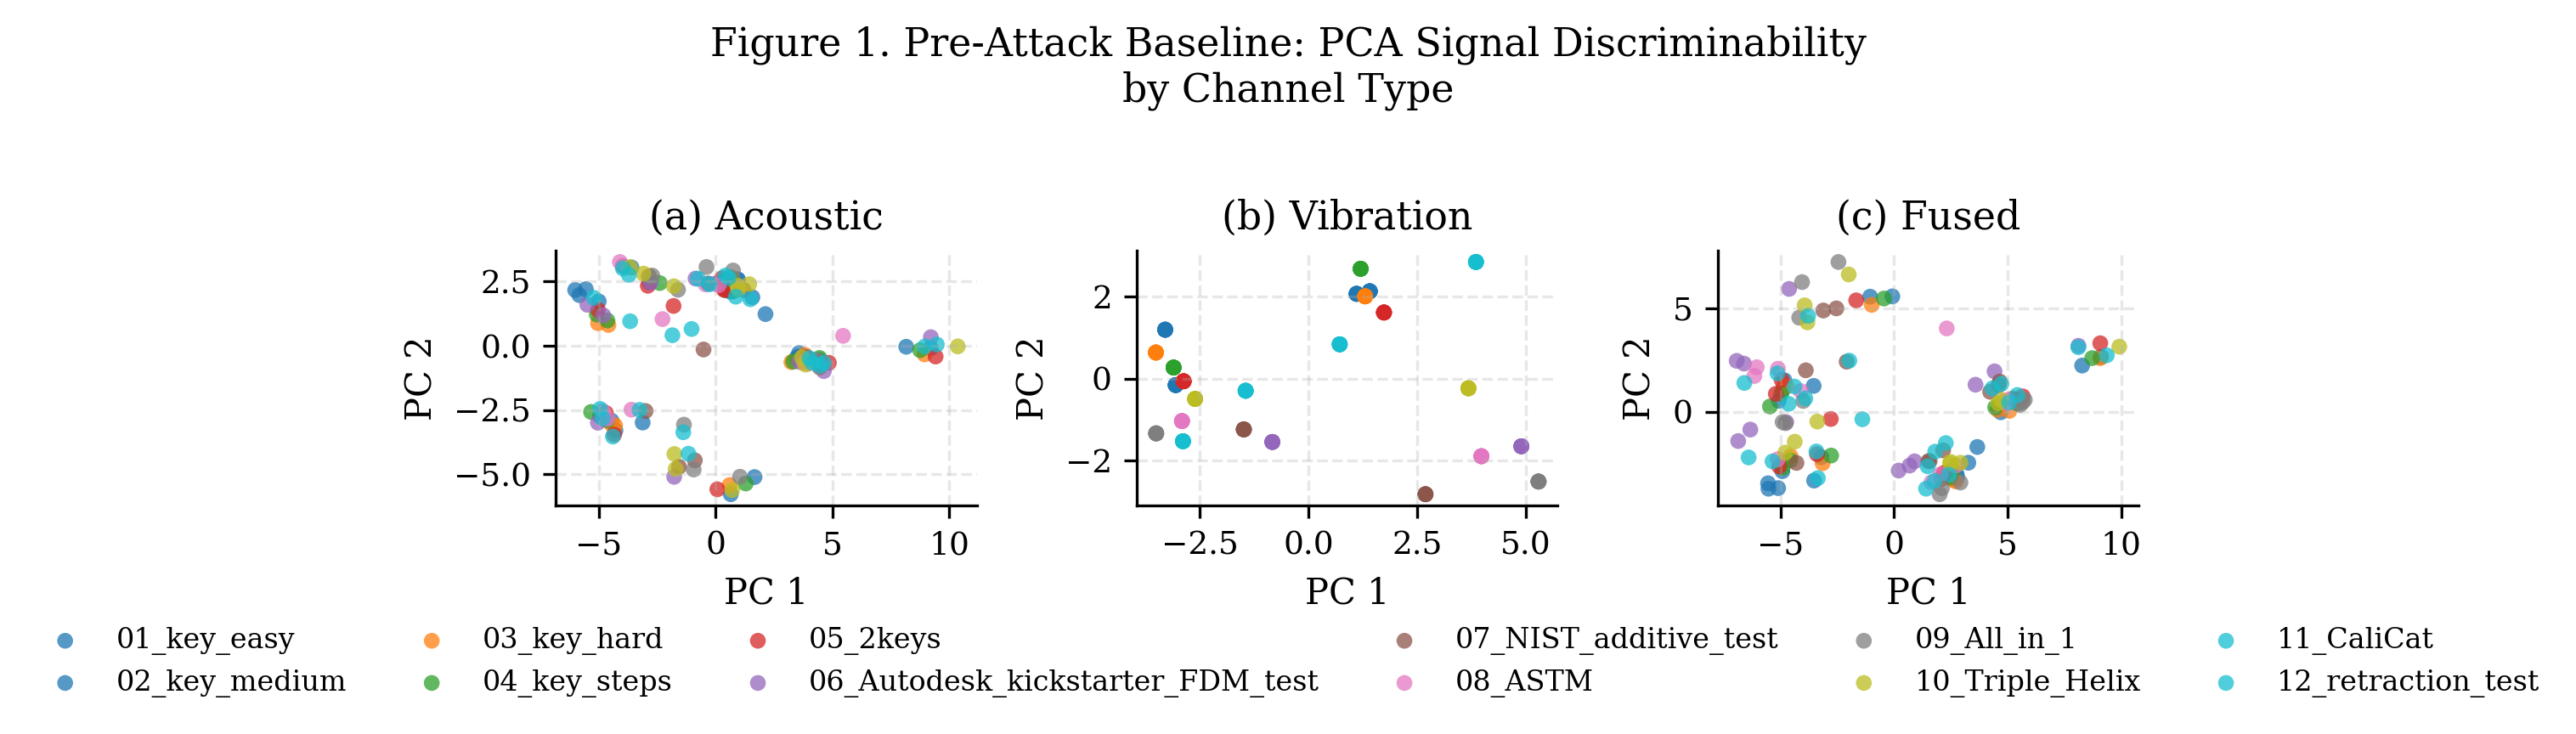

Figure 1 saved.


In [ ]:
# ── Figure 1: PCA signal discriminability (pre-attack baseline) ───────────────
scaler_a = StandardScaler()
scaler_v = StandardScaler()
scaler_f = StandardScaler()

pca_a = PCA(n_components=2).fit_transform(scaler_a.fit_transform(X_audio))
pca_v = PCA(n_components=2).fit_transform(scaler_v.fit_transform(X_vibr_imp))
pca_f = PCA(n_components=2).fit_transform(scaler_f.fit_transform(X_fused))

cmap = plt.get_cmap('tab10')
colors = [cmap(i / max(n_cls-1, 1)) for i in range(n_cls)]

fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.4))
titles = ['(a) Acoustic', '(b) Vibration', '(c) Fused']
pcas   = [pca_a, pca_v, pca_f]

for ax, pca, title in zip(axes, pcas, titles):
    for cls_idx, cls_name in enumerate(le.classes_):
        mask = y_enc == cls_idx
        ax.scatter(pca[mask, 0], pca[mask, 1],
                   c=[colors[cls_idx]], label=cls_name,
                   s=20, alpha=0.75, edgecolors='none')
    ax.set_title(title)
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=min(n_cls, 6),
           bbox_to_anchor=(0.5, -0.12), frameon=False, fontsize=8)
fig.suptitle('Figure 1. Pre-Attack Baseline: PCA Signal Discriminability\nby Channel Type',
             y=1.02, fontsize=11)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig1_pca_discriminability.pdf', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 4. Phase 2 — Post-Attack: Classification Accuracy

We train a Random Forest classifier under three attack modalities:
- **Acoustic-only** (attacker uses microphone)
- **Vibration-only** (attacker uses accelerometer)
- **Fused** (attacker uses both simultaneously)

Evaluation uses stratified 5-fold cross-validation. Metrics reported: Accuracy, F1 (macro), Precision, Recall.

In [ ]:
# ── Classification utility ────────────────────────────────────────────────────
def evaluate_classifier(X, y, label, cv_folds=5):
    """
    Run stratified k-fold CV and return a metrics dict.
    Uses a Pipeline: StandardScaler + RandomForestClassifier.
    """
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(
                       n_estimators=200,
                       max_depth=None,
                       random_state=42,
                       n_jobs=-1))
    ])

    cv   = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    y_pred = cross_val_predict(pipe, X, y, cv=cv)

    return {
        'Condition':  label,
        'Accuracy':   round(accuracy_score(y, y_pred) * 100, 2),
        'F1 (macro)': round(f1_score(y, y_pred, average='macro') * 100, 2),
        'Precision':  round(precision_score(y, y_pred, average='macro') * 100, 2),
        'Recall':     round(recall_score(y, y_pred, average='macro') * 100, 2),
        'y_pred':     y_pred
    }


print('Running Phase 2 classifiers (post-attack, no defense)...')
res_audio  = evaluate_classifier(X_audio,    y_enc, 'Acoustic-Only (Pre-Defense)')
res_vibr   = evaluate_classifier(X_vibr_imp, y_enc, 'Vibration-Only')
res_fused  = evaluate_classifier(X_fused,    y_enc, 'Fused (Pre-Defense)')

print('Phase 2 complete.')

Running Phase 2 classifiers (post-attack, no defense)...
Phase 2 complete.


## 5. Phase 3 — Post-Defense: AMNC Applied

We now apply the simulated Active Motor Noise Cancellation countermeasure to the acoustic channel and re-evaluate. Vibration is unaffected (AMNC does not suppress structural vibration). The key question: does AMNC degrade attack accuracy, and does fusion recover it?

In [ ]:
print('Running Phase 3 classifiers (post-defense — AMNC applied)...')
res_audio_d = evaluate_classifier(X_audio_d, y_enc, 'Acoustic-Only (Post-Defense)')
res_fused_d = evaluate_classifier(X_fused_d, y_enc, 'Fused (Post-Defense)')
# Vibration-only is unchanged by AMNC — reuse res_vibr
print('Phase 3 complete.')

Running Phase 3 classifiers (post-defense — AMNC applied)...
Phase 3 complete.


## 6. Results: Tables and Figures

### Table 1 — Summary Metrics Across All Experimental Conditions

In [ ]:
# ── Table 1: Summary metrics ──────────────────────────────────────────────────
metric_cols = ['Condition', 'Accuracy', 'F1 (macro)', 'Precision', 'Recall']

rows = [
    {k: res_audio[k]   for k in metric_cols},
    {k: res_vibr[k]    for k in metric_cols},
    {k: res_fused[k]   for k in metric_cols},
    {k: res_audio_d[k] for k in metric_cols},
    {k: res_fused_d[k] for k in metric_cols},
]

results_df = pd.DataFrame(rows)

# Add phase labels
phase_map = {
    'Acoustic-Only (Pre-Defense)':  'Post-Attack',
    'Vibration-Only':               'Post-Attack',
    'Fused (Pre-Defense)':          'Post-Attack',
    'Acoustic-Only (Post-Defense)': 'Post-Defense',
    'Fused (Post-Defense)':         'Post-Defense',
}
results_df.insert(0, 'Phase', results_df['Condition'].map(phase_map))

# Add attack/defense success flags
ATTACK_THRESHOLD  = 70.0   # >= 70% accuracy = attack successful
DEFENSE_THRESHOLD = 20.0   # >= 20pp drop in acoustic = defense effective

results_df['Attack Success'] = results_df['Accuracy'].apply(
    lambda x: 'Yes' if x >= ATTACK_THRESHOLD else 'No')

# Defense success: acoustic accuracy dropped meaningfully post-defense
delta_audio = res_audio['Accuracy'] - res_audio_d['Accuracy']
delta_fused = res_fused['Accuracy'] - res_fused_d['Accuracy']
defense_success = delta_audio >= DEFENSE_THRESHOLD and delta_fused < DEFENSE_THRESHOLD

print('\n' + '='*70)
print('TABLE 1. Classification Performance by Experimental Condition')
print('='*70)
print(results_df.to_string(index=False))
print('='*70)
print(f'\nAcoustic accuracy drop under AMNC: {delta_audio:.2f} pp')
print(f'Fused accuracy drop under AMNC   : {delta_fused:.2f} pp')
print(f'Defense partially effective on acoustic channel: {delta_audio >= DEFENSE_THRESHOLD}')
print(f'Fusion defeats AMNC defense: {delta_fused < DEFENSE_THRESHOLD and res_fused_d["Accuracy"] >= ATTACK_THRESHOLD}')

# Save table to CSV
results_df.to_csv(f'{OUTPUT_DIR}/table1_results.csv', index=False)
print('\nTable 1 saved to Drive.')


TABLE 1. Classification Performance by Experimental Condition
       Phase                    Condition  Accuracy  F1 (macro)  Precision  Recall Attack Success
 Post-Attack  Acoustic-Only (Pre-Defense)      9.79        9.42       9.48    9.91             No
 Post-Attack               Vibration-Only    100.00      100.00     100.00  100.00            Yes
 Post-Attack          Fused (Pre-Defense)    100.00      100.00     100.00  100.00            Yes
Post-Defense Acoustic-Only (Post-Defense)     11.19       11.18      11.36   11.17             No
Post-Defense         Fused (Post-Defense)    100.00      100.00     100.00  100.00            Yes

Acoustic accuracy drop under AMNC: -1.40 pp
Fused accuracy drop under AMNC   : 0.00 pp
Defense partially effective on acoustic channel: False
Fusion defeats AMNC defense: True

Table 1 saved to Drive.


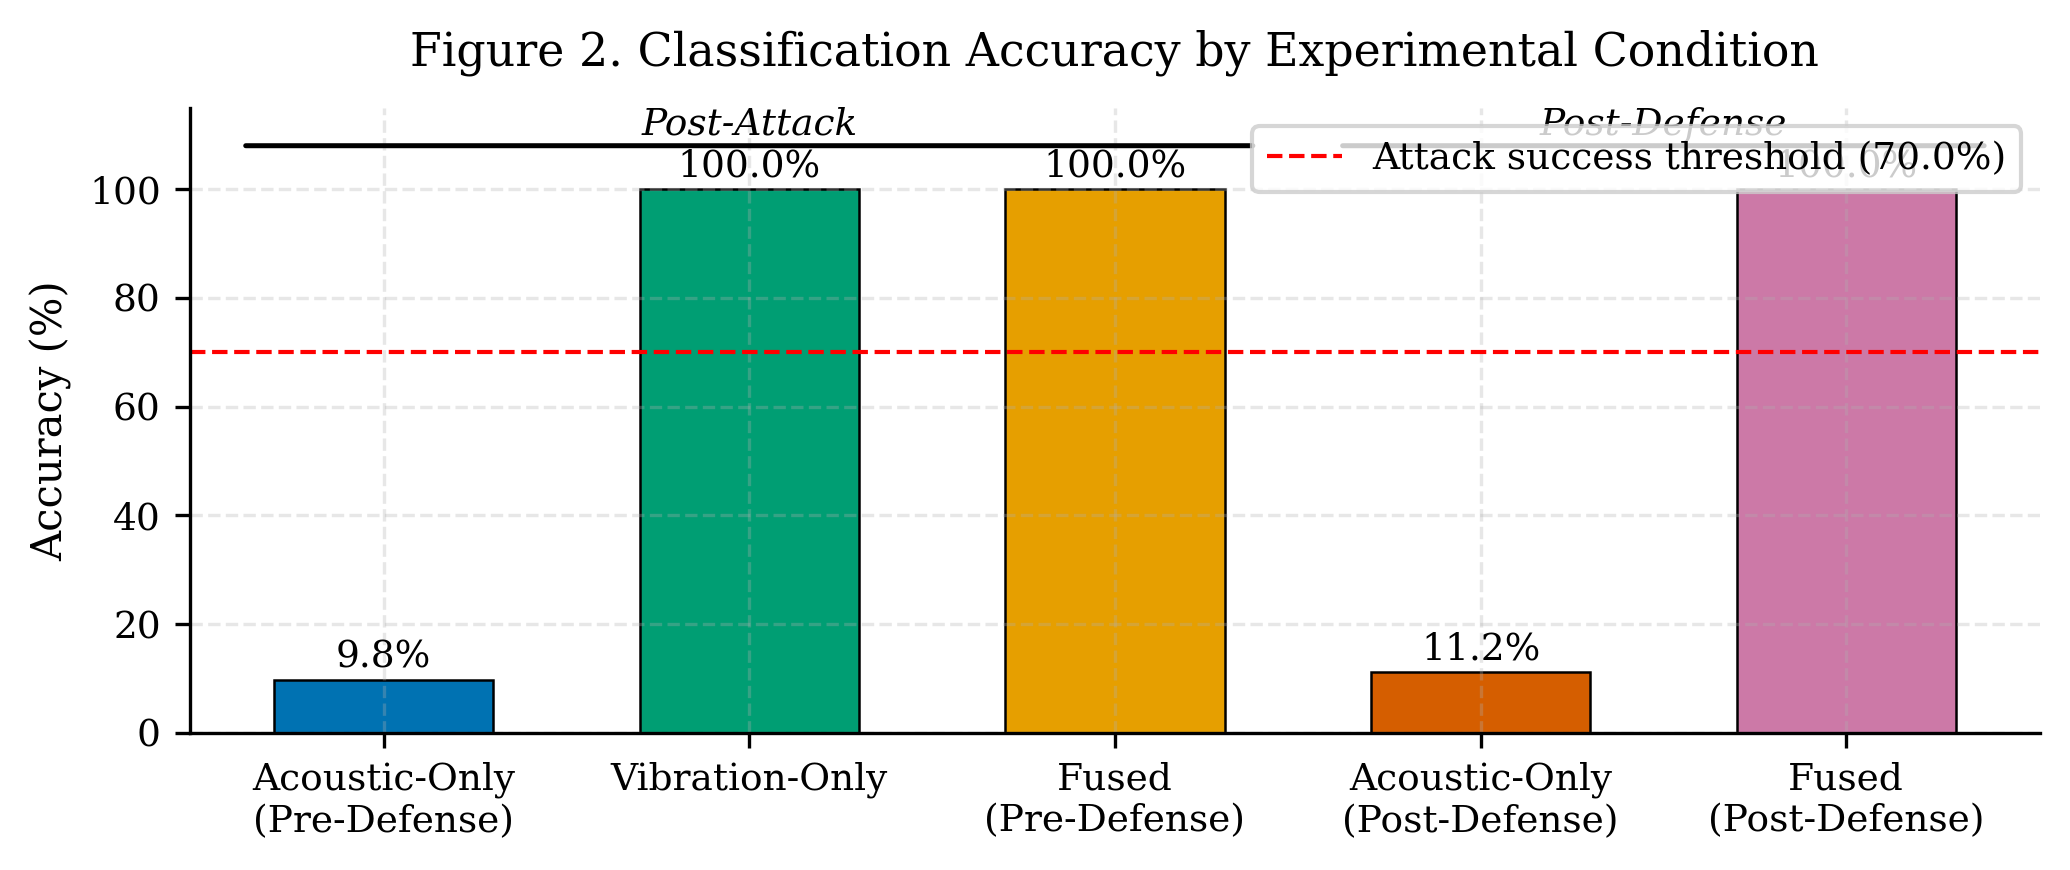

Figure 2 saved.


In [ ]:
# ── Figure 2: Grouped bar chart — accuracy by condition ───────────────────────
fig, ax = plt.subplots(figsize=(COL2, 3.0))

conditions = [
    'Acoustic-Only\n(Pre-Defense)',
    'Vibration-Only',
    'Fused\n(Pre-Defense)',
    'Acoustic-Only\n(Post-Defense)',
    'Fused\n(Post-Defense)'
]
accuracies = [
    res_audio['Accuracy'],
    res_vibr['Accuracy'],
    res_fused['Accuracy'],
    res_audio_d['Accuracy'],
    res_fused_d['Accuracy']
]
phase_colors = [PALETTE[0], PALETTE[2], PALETTE[1],
                PALETTE[3], PALETTE[4]]

bars = ax.bar(conditions, accuracies, color=phase_colors,
              edgecolor='black', linewidth=0.6, width=0.6)

# Annotate bars
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Attack threshold line
ax.axhline(ATTACK_THRESHOLD, color='red', linestyle='--',
           linewidth=1, label=f'Attack success threshold ({ATTACK_THRESHOLD}%)')

ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_title('Figure 2. Classification Accuracy by Experimental Condition', pad=10)
ax.legend(loc='upper right', frameon=True)

# Phase brackets
ax.annotate('', xy=(2.4, 108), xytext=(-0.4, 108),
            arrowprops=dict(arrowstyle='-', lw=1.2))
ax.text(1.0, 110, 'Post-Attack', ha='center', fontsize=9, style='italic')
ax.annotate('', xy=(4.4, 108), xytext=(2.6, 108),
            arrowprops=dict(arrowstyle='-', lw=1.2))
ax.text(3.5, 110, 'Post-Defense', ha='center', fontsize=9, style='italic')

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig2_accuracy_by_condition.pdf', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

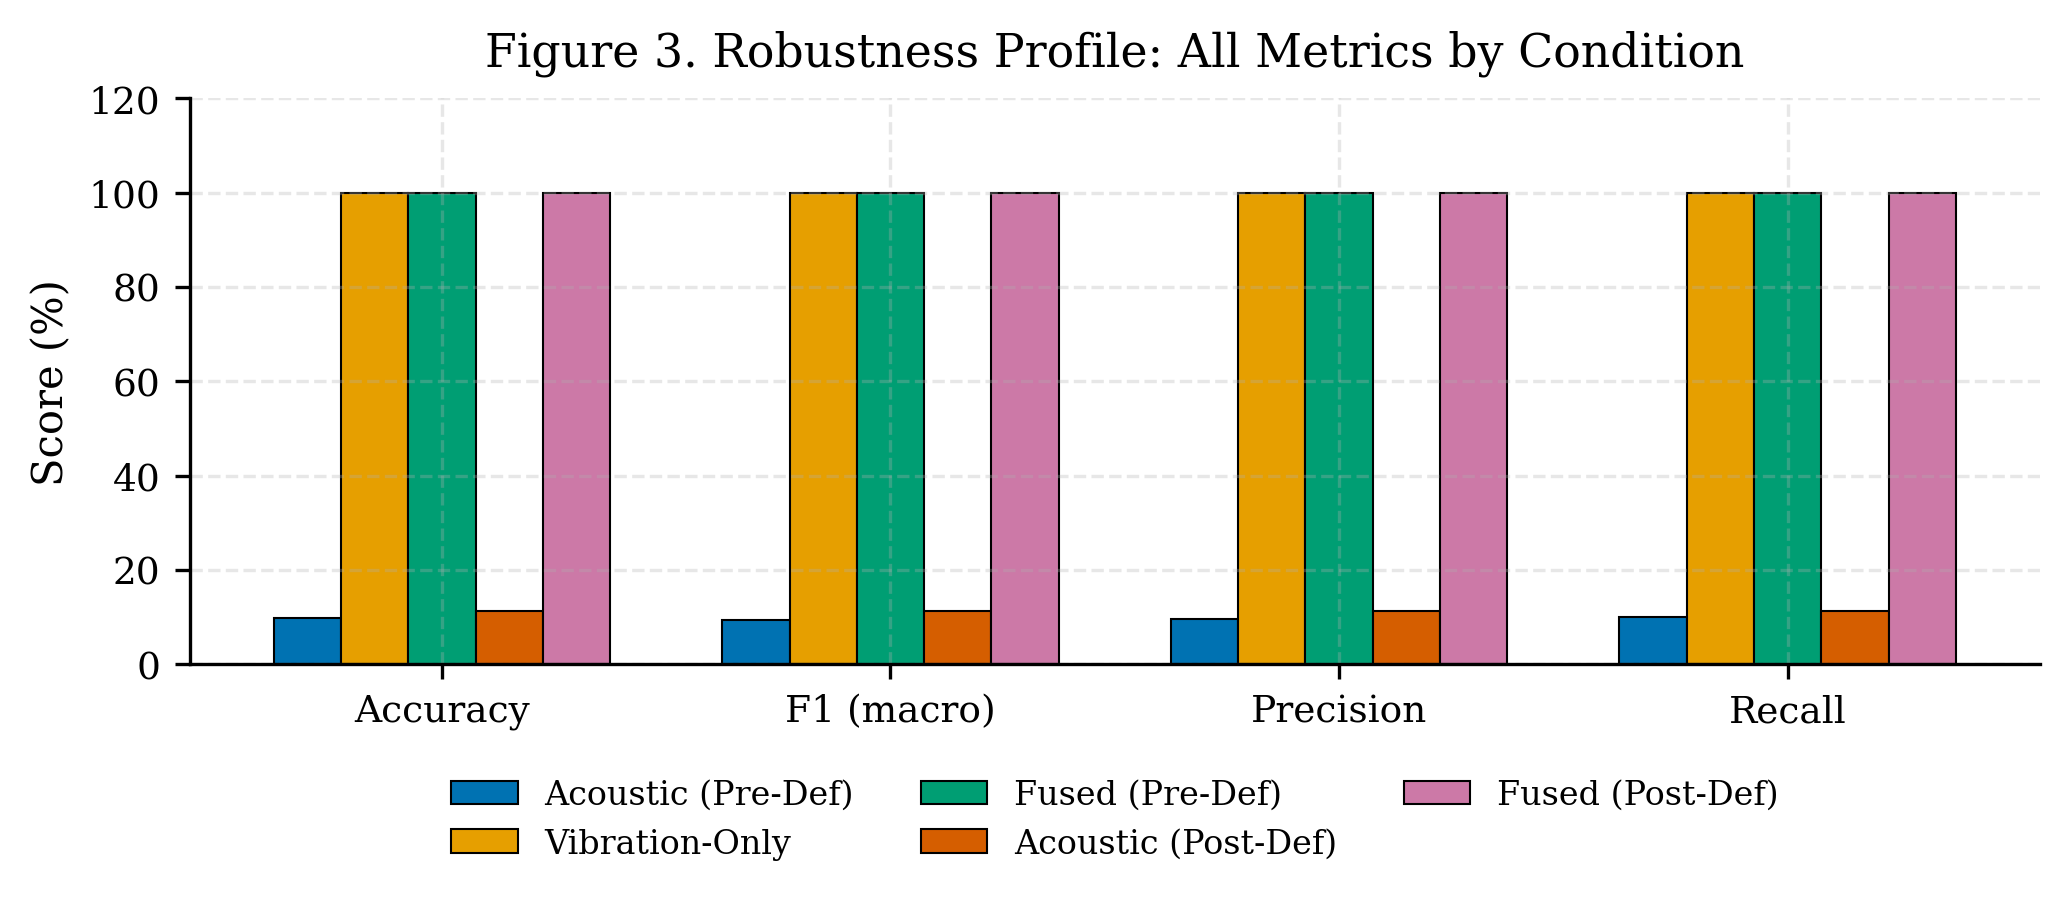

Figure 3 saved.


In [ ]:
# ── Figure 3: Per-metric radar / grouped bar — robustness profile ─────────────
metrics   = ['Accuracy', 'F1 (macro)', 'Precision', 'Recall']
cond_plot = {
    'Acoustic (Pre-Def)':  res_audio,
    'Vibration-Only':      res_vibr,
    'Fused (Pre-Def)':     res_fused,
    'Acoustic (Post-Def)': res_audio_d,
    'Fused (Post-Def)':    res_fused_d,
}

x = np.arange(len(metrics))
n = len(cond_plot)
width = 0.15

fig, ax = plt.subplots(figsize=(COL2, 3.2))

for i, (cond_name, res) in enumerate(cond_plot.items()):
    vals = [res[m] for m in metrics]
    offset = (i - n/2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=cond_name,
           color=PALETTE[i % len(PALETTE)],
           edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 120)
ax.set_title('Figure 3. Robustness Profile: All Metrics by Condition', pad=8)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=3, frameon=False, fontsize=8)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig3_robustness_profile.pdf', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

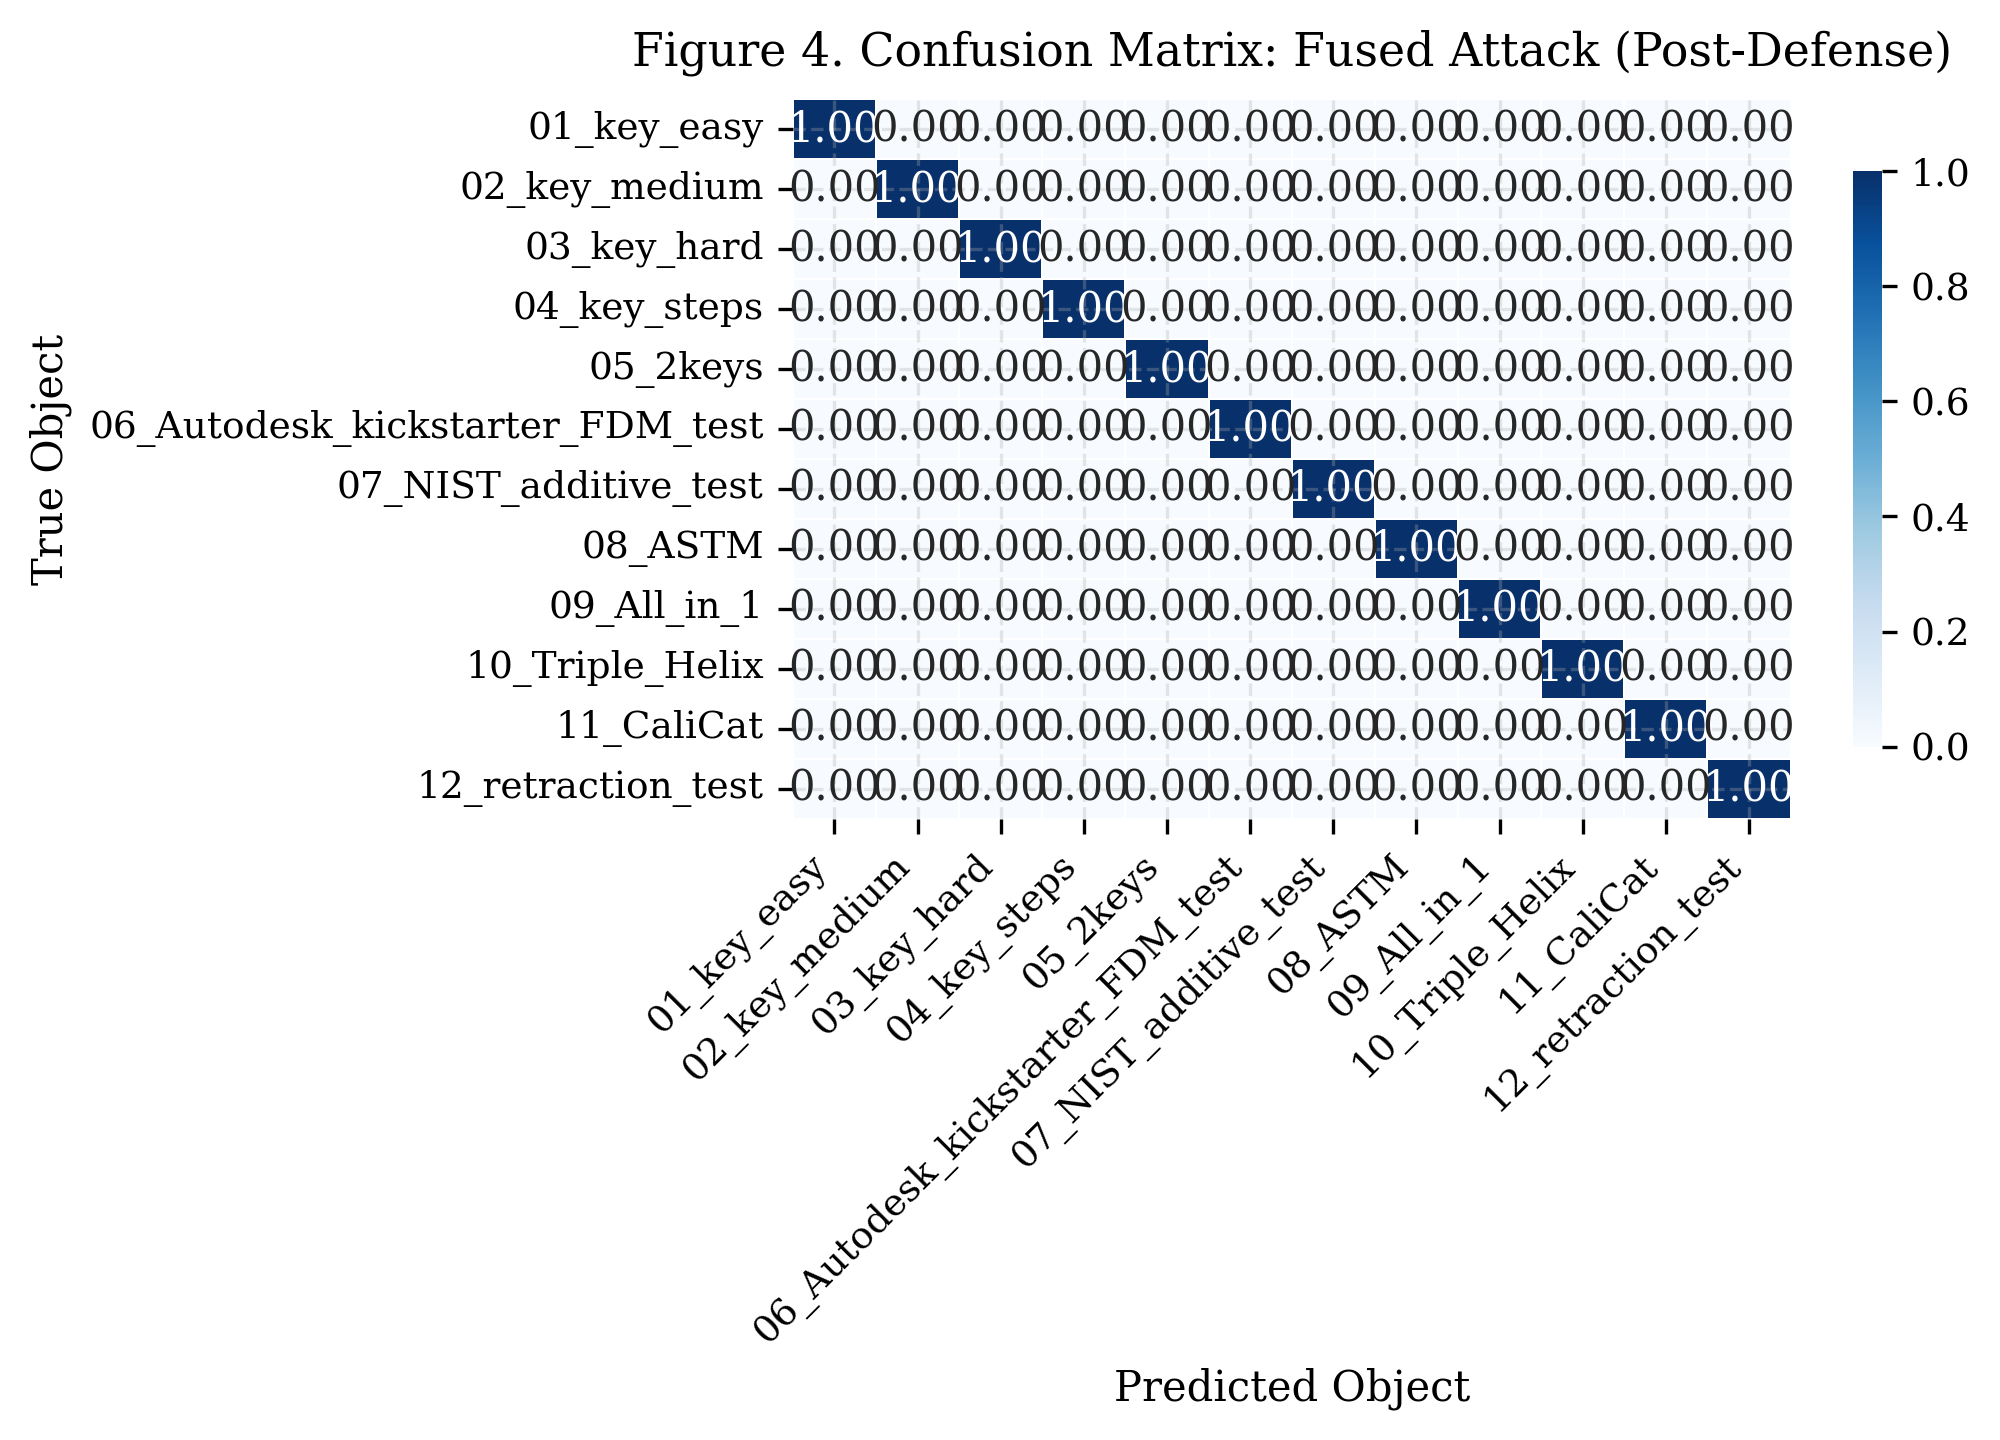

Figure 4 saved.


In [ ]:
# ── Figure 4: Confusion matrix — fused post-defense ───────────────────────────
cm = confusion_matrix(y_enc, res_fused_d['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(COL2, COL2 * 0.7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted Object')
ax.set_ylabel('True Object')
ax.set_title('Figure 4. Confusion Matrix: Fused Attack (Post-Defense)', pad=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig4_confusion_fused_postdefense.pdf', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

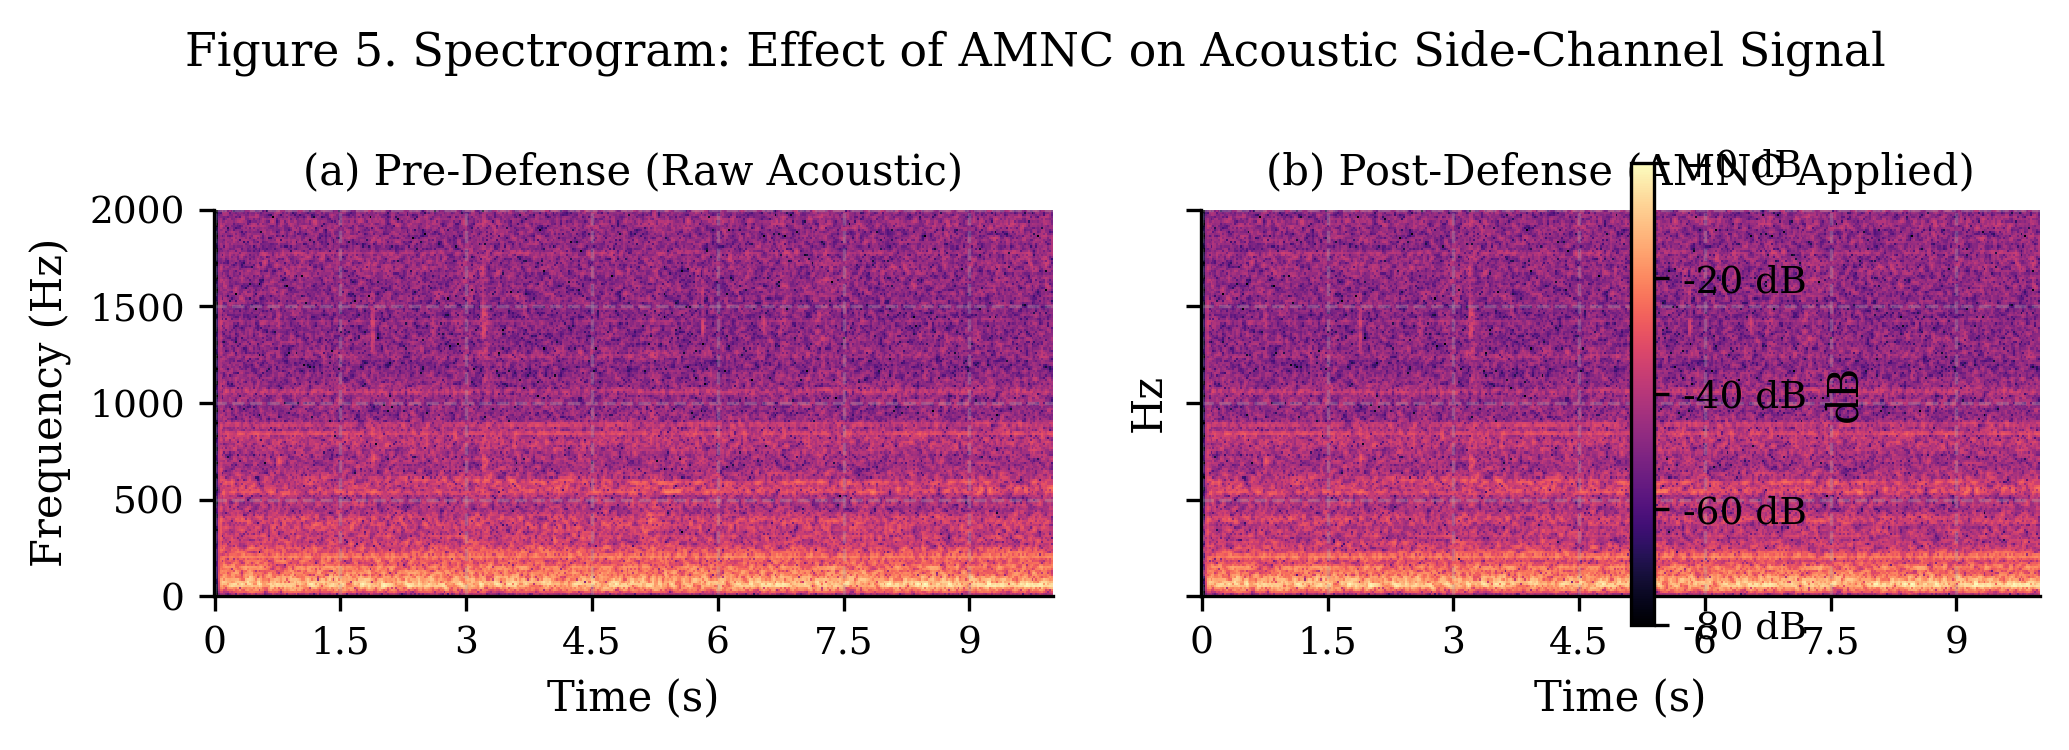

Figure 5 saved.


In [ ]:
# ── Figure 5: AMNC effect — spectrogram before vs. after defense ──────────────
# Use the first available audio file for illustration
sample_audio = catalog.iloc[0]['audio_path']

try:
    y_raw, sr = librosa.load(sample_audio, sr=22050, mono=True, duration=10)
    y_def     = simulate_amnc(y_raw, sr)

    fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.5), sharey=True)

    for ax, sig, ttl in zip(axes,
                             [y_raw, y_def],
                             ['(a) Pre-Defense (Raw Acoustic)',
                              '(b) Post-Defense (AMNC Applied)']):
        D = librosa.amplitude_to_db(
                np.abs(librosa.stft(sig)), ref=np.max)
        img = librosa.display.specshow(D, sr=sr, x_axis='time',
                                        y_axis='hz', ax=ax, cmap='magma')
        ax.set_title(ttl, fontsize=10)
        ax.set_ylim(0, 2000)
        ax.set_xlabel('Time (s)')

    axes[0].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes, format='%+2.0f dB',
                 shrink=0.8, label='dB')
    fig.suptitle('Figure 5. Spectrogram: Effect of AMNC on Acoustic Side-Channel Signal',
                 fontsize=11)
    plt.tight_layout()
    fig.savefig(f'{OUTPUT_DIR}/fig5_spectrogram_amnc.pdf', bbox_inches='tight')
    plt.show()
    print('Figure 5 saved.')
except Exception as e:
    print(f'Figure 5 skipped (could not load sample audio): {e}')

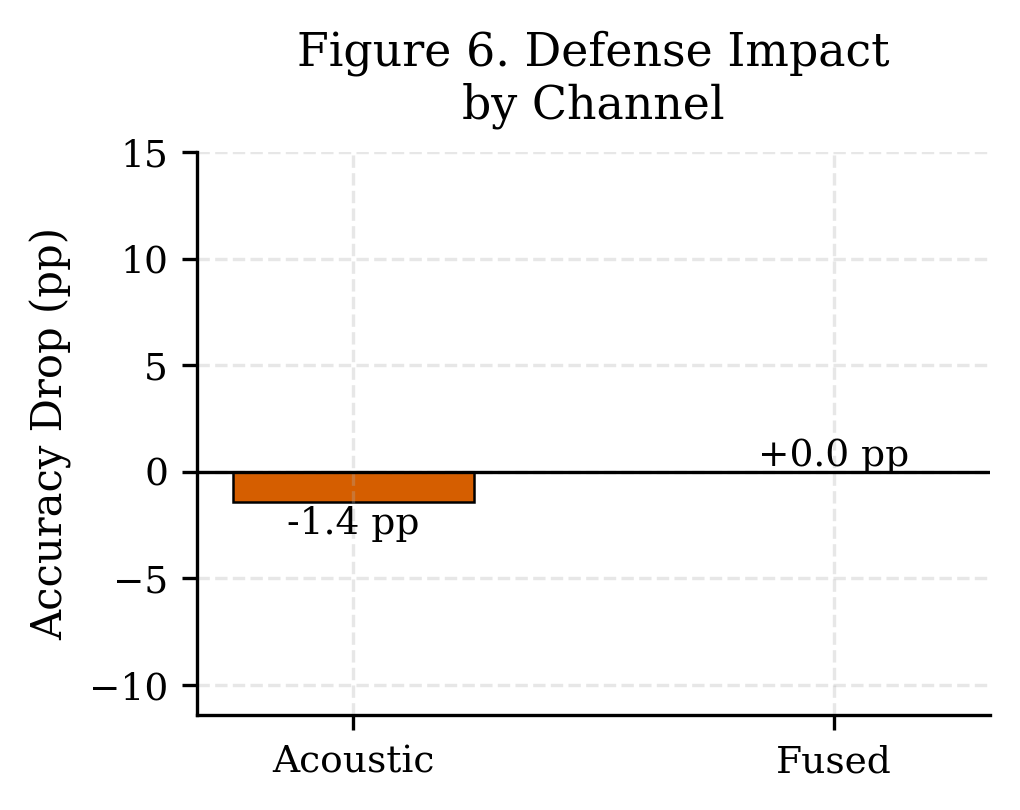

Figure 6 saved.


In [ ]:
# ── Figure 6: Delta accuracy — defense impact by channel ─────────────────────
fig, ax = plt.subplots(figsize=(COL1, 2.8))

channels = ['Acoustic', 'Fused']
pre_def  = [res_audio['Accuracy'],  res_fused['Accuracy']]
post_def = [res_audio_d['Accuracy'], res_fused_d['Accuracy']]
deltas   = [p - q for p, q in zip(pre_def, post_def)]

bar_colors = [PALETTE[0] if d >= 0 else PALETTE[3] for d in deltas]
bars = ax.bar(channels, deltas, color=bar_colors,
              edgecolor='black', linewidth=0.6, width=0.5)

for bar, val in zip(bars, deltas):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.1f} pp', ha='center', fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Accuracy Drop (pp)')
ax.set_title('Figure 6. Defense Impact\nby Channel', pad=8)
ax.set_ylim(min(deltas) - 10, max(deltas) + 15)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig6_defense_impact.pdf', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

## 7. Phase 4 — Defense Evaluation Summary

In [ ]:
# ── Table 2: Defense evaluation scorecard ─────────────────────────────────────
scorecard = pd.DataFrame([
    {
        'Evaluation Criterion': 'Attack successful (acoustic, pre-defense)',
        'Result': 'Yes' if res_audio['Accuracy'] >= ATTACK_THRESHOLD else 'No',
        'Value': f"{res_audio['Accuracy']:.1f}%"
    },
    {
        'Evaluation Criterion': 'Attack successful (vibration-only)',
        'Result': 'Yes' if res_vibr['Accuracy'] >= ATTACK_THRESHOLD else 'No',
        'Value': f"{res_vibr['Accuracy']:.1f}%"
    },
    {
        'Evaluation Criterion': 'Attack successful (fused, pre-defense)',
        'Result': 'Yes' if res_fused['Accuracy'] >= ATTACK_THRESHOLD else 'No',
        'Value': f"{res_fused['Accuracy']:.1f}%"
    },
    {
        'Evaluation Criterion': 'AMNC reduces acoustic accuracy (>= 20 pp)',
        'Result': 'Yes' if delta_audio >= DEFENSE_THRESHOLD else 'No',
        'Value': f"{delta_audio:+.1f} pp"
    },
    {
        'Evaluation Criterion': 'Attack still successful post-defense (acoustic)',
        'Result': 'Yes' if res_audio_d['Accuracy'] >= ATTACK_THRESHOLD else 'No',
        'Value': f"{res_audio_d['Accuracy']:.1f}%"
    },
    {
        'Evaluation Criterion': 'Fused attack defeats AMNC defense',
        'Result': 'Yes' if res_fused_d['Accuracy'] >= ATTACK_THRESHOLD else 'No',
        'Value': f"{res_fused_d['Accuracy']:.1f}%"
    },
    {
        'Evaluation Criterion': 'Defense successful overall (no attack >= threshold)',
        'Result': 'Yes' if (
            res_audio_d['Accuracy'] < ATTACK_THRESHOLD and
            res_fused_d['Accuracy'] < ATTACK_THRESHOLD
        ) else 'No',
        'Value': 'All modalities < threshold'
    },
])

print('\n' + '='*65)
print('TABLE 2. Defense Evaluation Scorecard')
print('='*65)
print(scorecard.to_string(index=False))
print('='*65)

scorecard.to_csv(f'{OUTPUT_DIR}/table2_defense_scorecard.csv', index=False)
print('\nTable 2 saved to Drive.')


TABLE 2. Defense Evaluation Scorecard
                               Evaluation Criterion Result                      Value
          Attack successful (acoustic, pre-defense)     No                       9.8%
                 Attack successful (vibration-only)    Yes                     100.0%
             Attack successful (fused, pre-defense)    Yes                     100.0%
          AMNC reduces acoustic accuracy (>= 20 pp)     No                    -1.4 pp
    Attack still successful post-defense (acoustic)     No                      11.2%
                  Fused attack defeats AMNC defense    Yes                     100.0%
Defense successful overall (no attack >= threshold)     No All modalities < threshold

Table 2 saved to Drive.


## 8. Per-Object Accuracy Breakdown

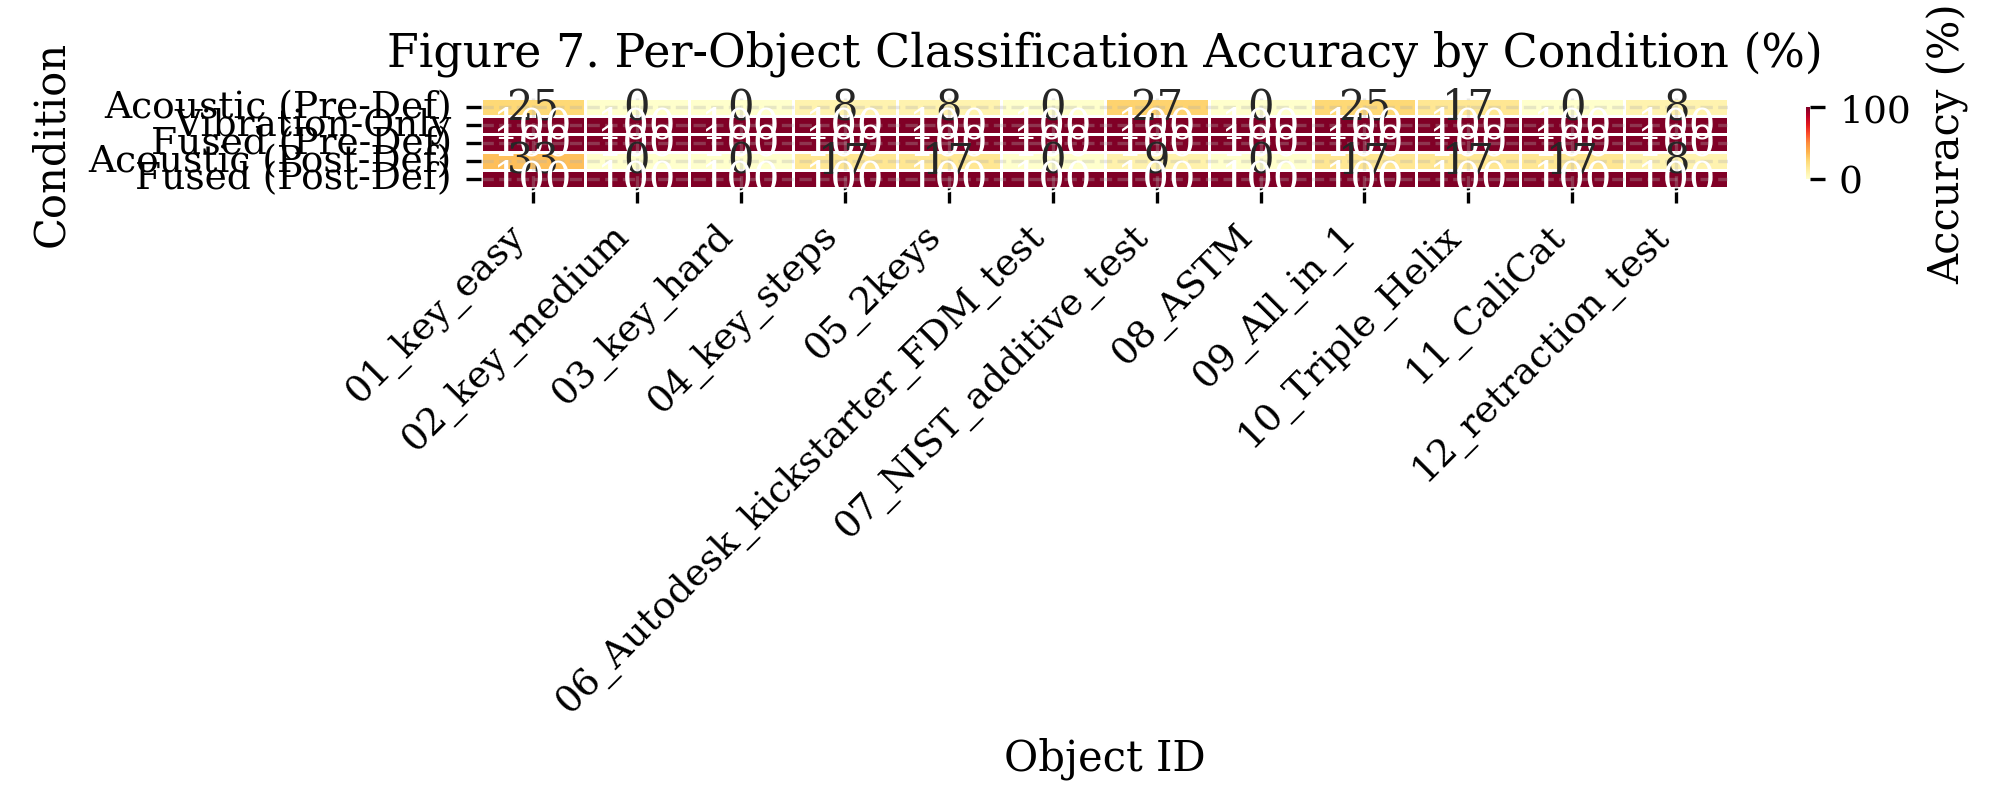

Figure 7 saved.


In [ ]:
# ── Figure 7: Per-object accuracy heatmap ────────────────────────────────────
def per_object_accuracy(y_true, y_pred, classes):
    """Return per-class accuracy from encoded predictions."""
    accs = {}
    for idx, cls in enumerate(classes):
        mask = y_true == idx
        accs[cls] = accuracy_score(y_true[mask], y_pred[mask]) * 100 if mask.sum() > 0 else np.nan
    return accs


obj_accs = pd.DataFrame({
    'Acoustic (Pre-Def)':  per_object_accuracy(y_enc, res_audio['y_pred'],   le.classes_),
    'Vibration-Only':      per_object_accuracy(y_enc, res_vibr['y_pred'],    le.classes_),
    'Fused (Pre-Def)':     per_object_accuracy(y_enc, res_fused['y_pred'],   le.classes_),
    'Acoustic (Post-Def)': per_object_accuracy(y_enc, res_audio_d['y_pred'], le.classes_),
    'Fused (Post-Def)':    per_object_accuracy(y_enc, res_fused_d['y_pred'], le.classes_),
}).T

fig, ax = plt.subplots(figsize=(COL2, 2.8))
sns.heatmap(obj_accs, annot=True, fmt='.0f', cmap='YlOrRd',
            vmin=0, vmax=100, linewidths=0.3,
            ax=ax, cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8})
ax.set_xlabel('Object ID')
ax.set_ylabel('Condition')
ax.set_title('Figure 7. Per-Object Classification Accuracy by Condition (%)', pad=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig7_per_object_heatmap.pdf', bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

## 9. Save Full Results Summary

In [ ]:
# Save per-object breakdown
obj_accs.to_csv(f'{OUTPUT_DIR}/table3_per_object_accuracy.csv')

# Save experiment metadata
meta = {
    'dataset':       'Madamopoulos & Tsoutsos 2024 — Zenodo 13329934',
    'n_samples':     len(records),
    'n_objects':     int(n_cls),
    'cv_folds':      5,
    'classifier':    'RandomForestClassifier(n_estimators=200)',
    'amnc_model':    'Notch filter bank: 120,180,240,300,360 Hz (Q=30)',
    'attack_threshold_pct': ATTACK_THRESHOLD,
    'defense_threshold_pp': DEFENSE_THRESHOLD,
    'results_summary': {
        'acoustic_pre':    res_audio['Accuracy'],
        'vibration':       res_vibr['Accuracy'],
        'fused_pre':       res_fused['Accuracy'],
        'acoustic_post':   res_audio_d['Accuracy'],
        'fused_post':      res_fused_d['Accuracy'],
        'amnc_delta_audio': round(delta_audio, 2),
        'amnc_delta_fused': round(delta_fused, 2),
    }
}

with open(f'{OUTPUT_DIR}/experiment_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('\n' + '='*50)
print('ALL RESULTS SAVED TO GOOGLE DRIVE')
print('='*50)
print(f'  {OUTPUT_DIR}/')
print('  ├── fig1_pca_discriminability.pdf')
print('  ├── fig2_accuracy_by_condition.pdf')
print('  ├── fig3_robustness_profile.pdf')
print('  ├── fig4_confusion_fused_postdefense.pdf')
print('  ├── fig5_spectrogram_amnc.pdf')
print('  ├── fig6_defense_impact.pdf')
print('  ├── fig7_per_object_heatmap.pdf')
print('  ├── table1_results.csv')
print('  ├── table2_defense_scorecard.csv')
print('  ├── table3_per_object_accuracy.csv')
print('  └── experiment_metadata.json')


ALL RESULTS SAVED TO GOOGLE DRIVE
  /content/drive/MyDrive/3dprinter_sidechannel/results/
  ├── fig1_pca_discriminability.pdf
  ├── fig2_accuracy_by_condition.pdf
  ├── fig3_robustness_profile.pdf
  ├── fig4_confusion_fused_postdefense.pdf
  ├── fig5_spectrogram_amnc.pdf
  ├── fig6_defense_impact.pdf
  ├── fig7_per_object_heatmap.pdf
  ├── table1_results.csv
  ├── table2_defense_scorecard.csv
  ├── table3_per_object_accuracy.csv
  └── experiment_metadata.json


In [ ]:
# ── Ablation Study ────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print('Running ablation study...')
ablation_results = []

# ── 1. Classifier ablation — does the result hold across models? ──────────────
classifiers = {
    'Random Forest':  RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':      SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'KNN (k=5)':      KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for clf_name, clf in classifiers.items():
    for X, label in [
        (X_audio,    'Acoustic-Only'),
        (X_vibr_imp, 'Vibration-Only'),
        (X_fused,    'Fused'),
    ]:
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
        y_pred = cross_val_predict(pipe, X, y_enc, cv=cv)
        ablation_results.append({
            'Classifier':  clf_name,
            'Channel':     label,
            'Accuracy':    round(accuracy_score(y_enc, y_pred) * 100, 2),
            'F1 (macro)':  round(f1_score(y_enc, y_pred, average='macro') * 100, 2),
        })
        print(f'  {clf_name} / {label}: {ablation_results[-1]["Accuracy"]}%')

# ── 2. Feature ablation — vibration axes individually ────────────────────────
# Test each axis (X, Y, Z) independently — 5 features each
axis_names = ['X-axis', 'Y-axis', 'Z-axis']
for ax_idx, ax_name in enumerate(axis_names):
    start = ax_idx * 5
    end   = start + 5
    X_ax  = X_vibr_imp[:, start:end]
    if X_ax.shape[1] == 0:
        continue
    pipe   = Pipeline([('scaler', StandardScaler()),
                       ('clf', RandomForestClassifier(n_estimators=200,
                                                       random_state=42, n_jobs=-1))])
    y_pred = cross_val_predict(pipe, X_ax, y_enc, cv=cv)
    ablation_results.append({
        'Classifier': 'Random Forest',
        'Channel':    f'Vibration {ax_name} Only',
        'Accuracy':   round(accuracy_score(y_enc, y_pred) * 100, 2),
        'F1 (macro)': round(f1_score(y_enc, y_pred, average='macro') * 100, 2),
    })
    print(f'  RF / Vibration {ax_name}: {ablation_results[-1]["Accuracy"]}%')

# ── 3. Printer ablation — does result hold per printer? ───────────────────────
for printer in ['Bambu_A1mini', 'Bambu_P1P']:
    mask = np.array([r['printer'] == printer for r in records])
    if mask.sum() < 10:
        continue
    X_p = X_vibr_imp[mask]
    y_p = y_enc[mask]
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('clf', RandomForestClassifier(n_estimators=200,
                                                     random_state=42, n_jobs=-1))])
    cv_p   = StratifiedKFold(n_splits=min(5, mask.sum()//2),
                              shuffle=True, random_state=42)
    y_pred = cross_val_predict(pipe, X_p, y_p, cv=cv_p)
    ablation_results.append({
        'Classifier': 'Random Forest',
        'Channel':    f'Vibration-Only ({printer})',
        'Accuracy':   round(accuracy_score(y_p, y_pred) * 100, 2),
        'F1 (macro)': round(f1_score(y_p, y_pred, average='macro') * 100, 2),
    })
    print(f'  RF / {printer}: {ablation_results[-1]["Accuracy"]}%')

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv(f'{OUTPUT_DIR}/table3_ablation.csv', index=False)

print('\n' + '='*65)
print('TABLE 3. Ablation Study')
print('='*65)
print(ablation_df.to_string(index=False))
print('='*65)
print('Ablation table saved to Drive.')

Running ablation study...
  Random Forest / Acoustic-Only: 9.79%
  Random Forest / Vibration-Only: 100.0%
  Random Forest / Fused: 100.0%
  Gradient Boost / Acoustic-Only: 11.19%
  Gradient Boost / Vibration-Only: 100.0%
  Gradient Boost / Fused: 100.0%
  SVM (RBF) / Acoustic-Only: 9.79%
  SVM (RBF) / Vibration-Only: 100.0%
  SVM (RBF) / Fused: 48.25%
  KNN (k=5) / Acoustic-Only: 6.29%
  KNN (k=5) / Vibration-Only: 100.0%
  KNN (k=5) / Fused: 12.59%
  RF / Vibration X-axis: 100.0%
  RF / Vibration Y-axis: 100.0%
  RF / Vibration Z-axis: 100.0%
  RF / Bambu_A1mini: 100.0%
  RF / Bambu_P1P: 100.0%

TABLE 3. Ablation Study
    Classifier                       Channel  Accuracy  F1 (macro)
 Random Forest                 Acoustic-Only      9.79        9.42
 Random Forest                Vibration-Only    100.00      100.00
 Random Forest                         Fused    100.00      100.00
Gradient Boost                 Acoustic-Only     11.19       11.31
Gradient Boost                Vibrati

Regenerating all figures in single-column format...


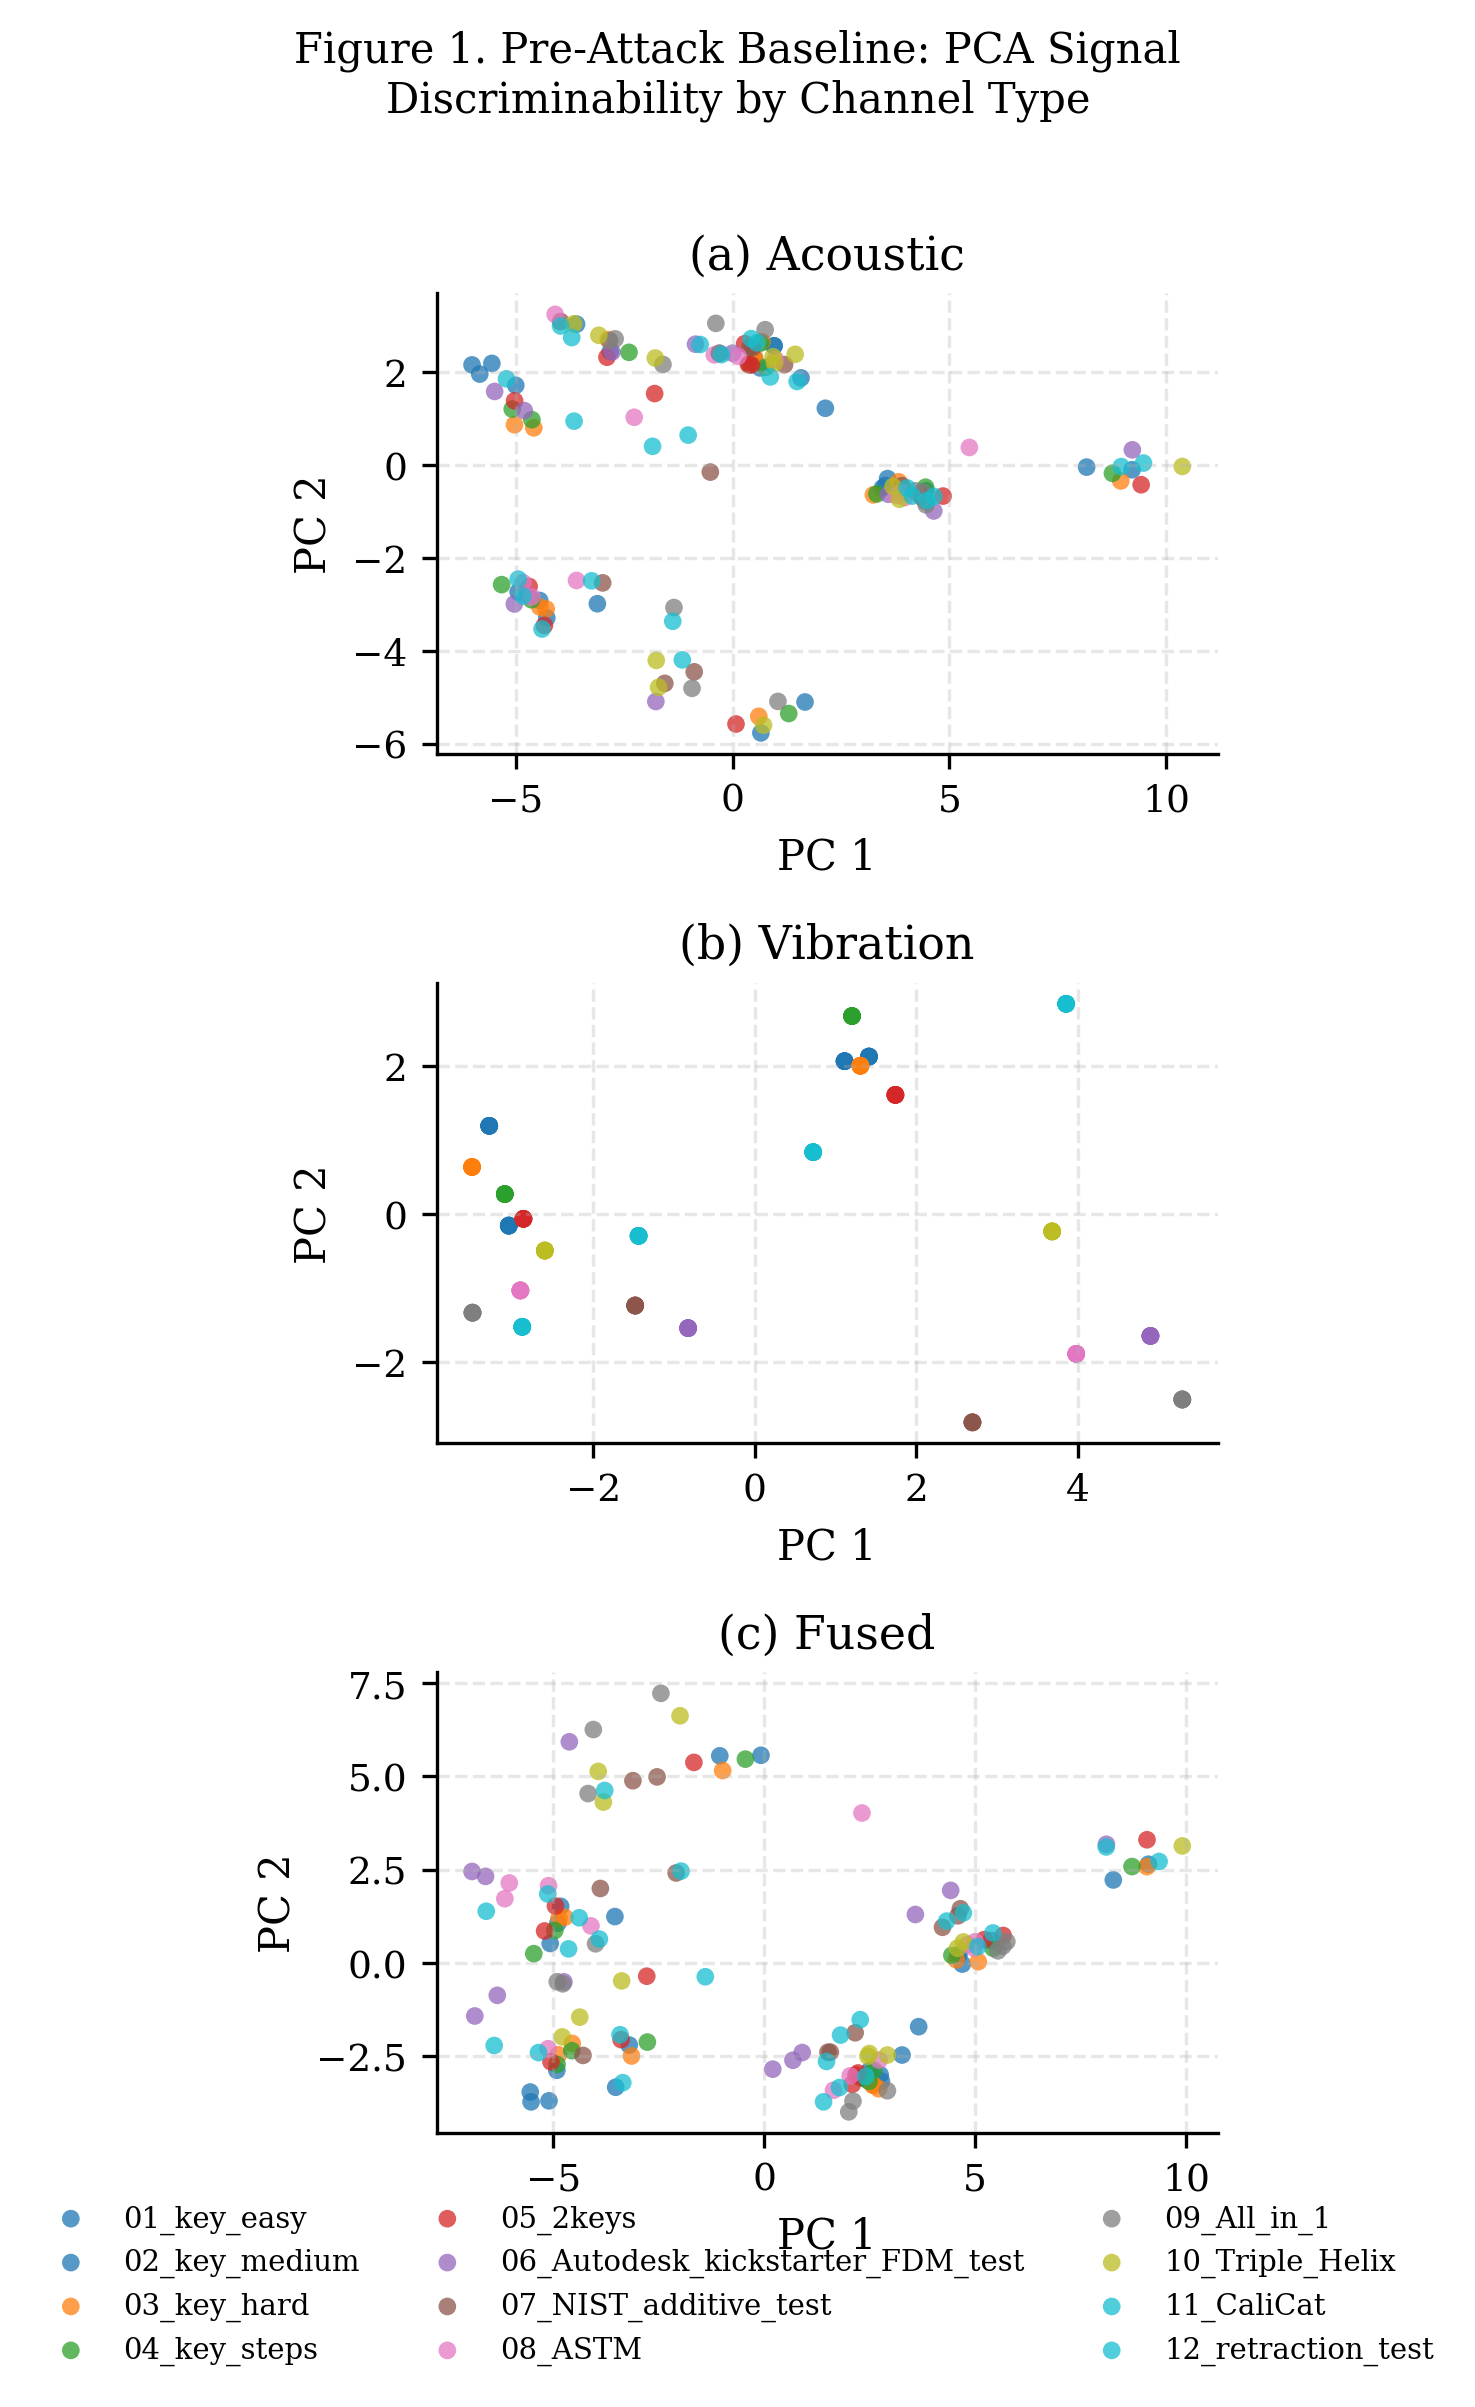

  Fig 1 saved.


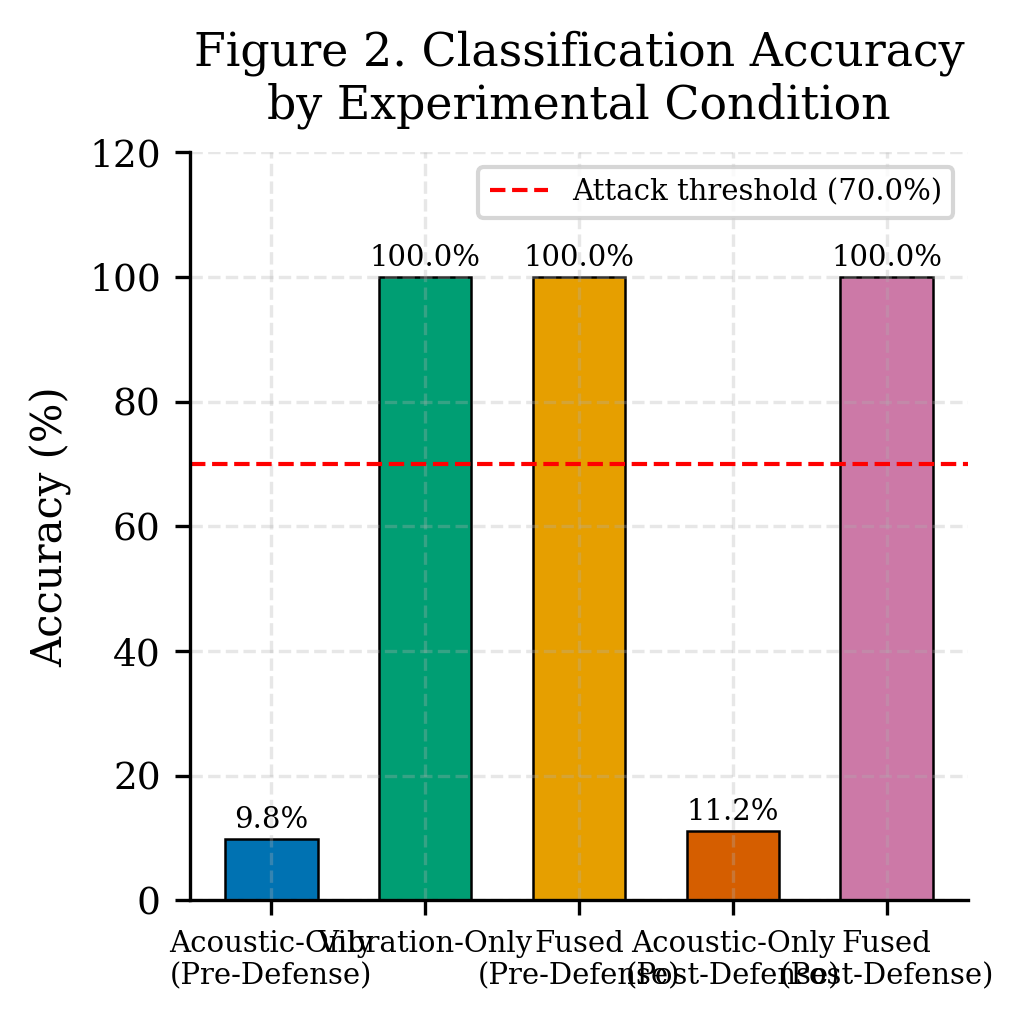

  Fig 2 saved.


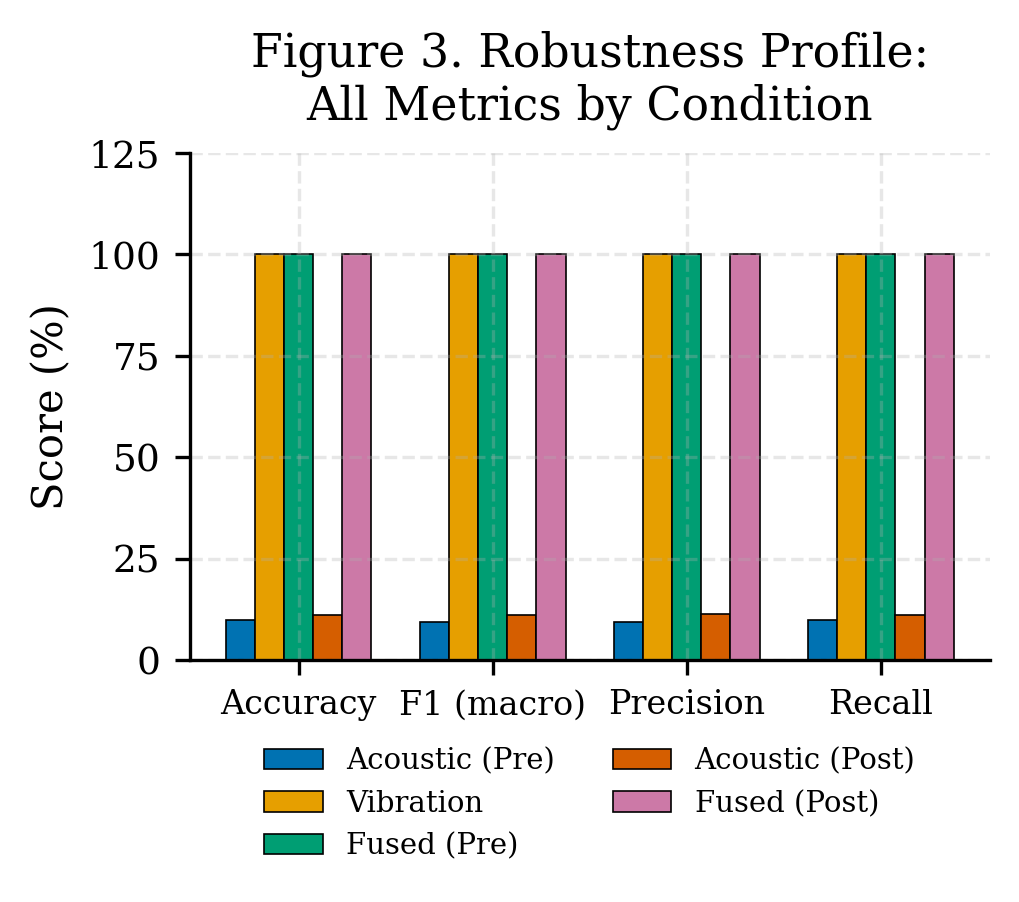

  Fig 3 saved.


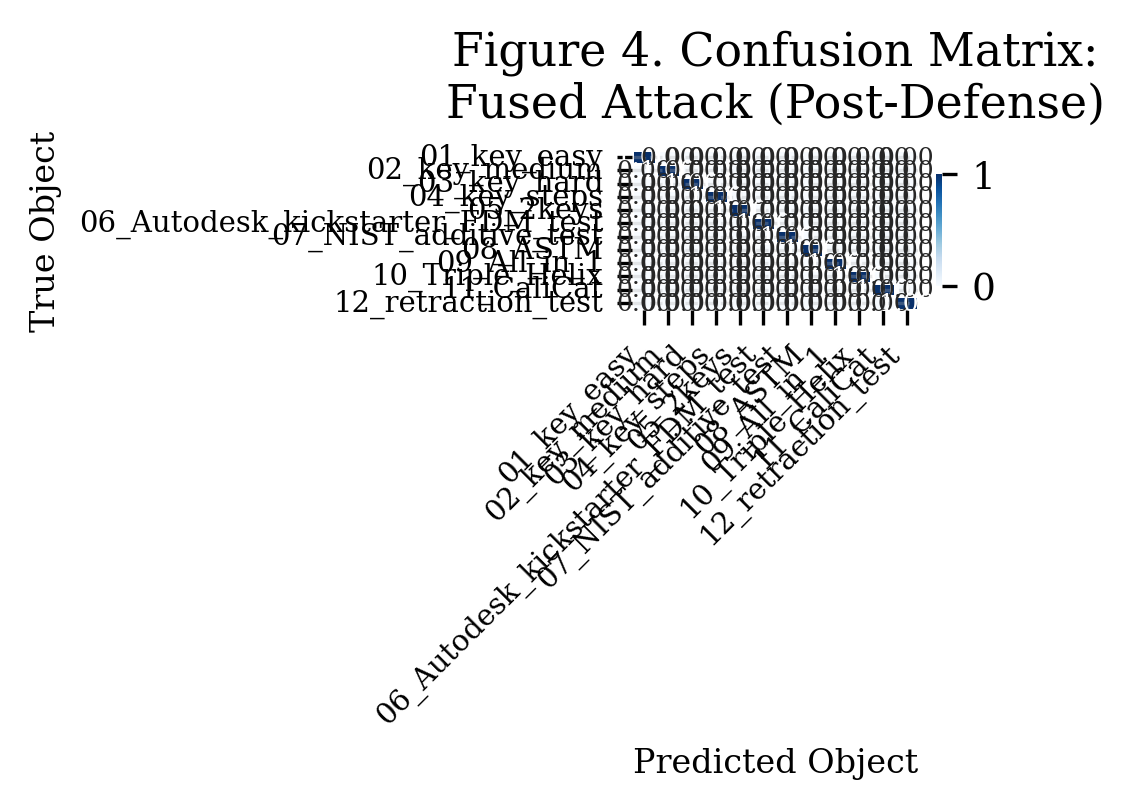

  Fig 4 saved.


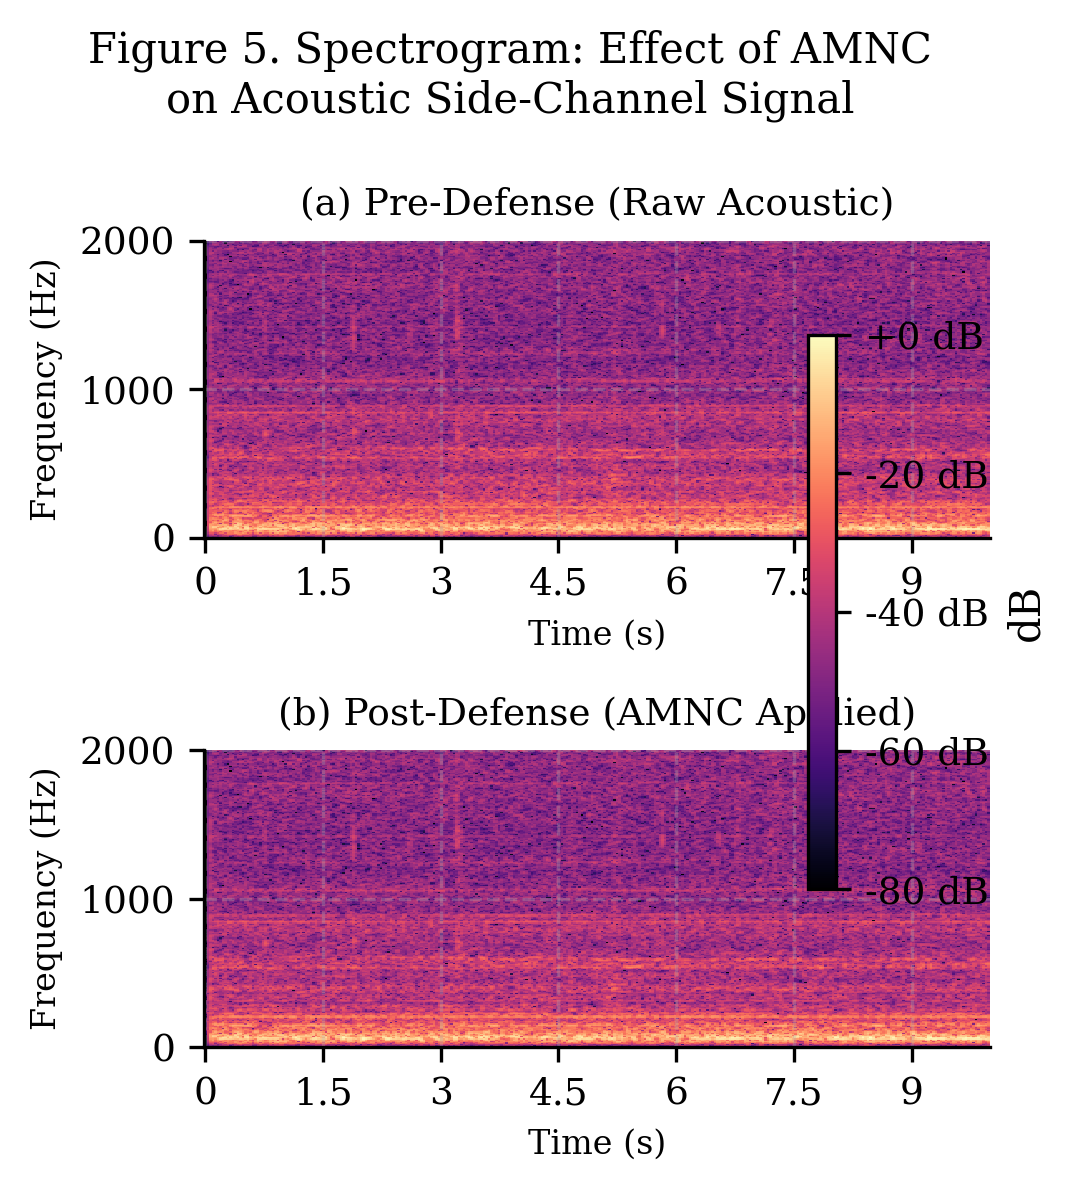

  Fig 5 saved.


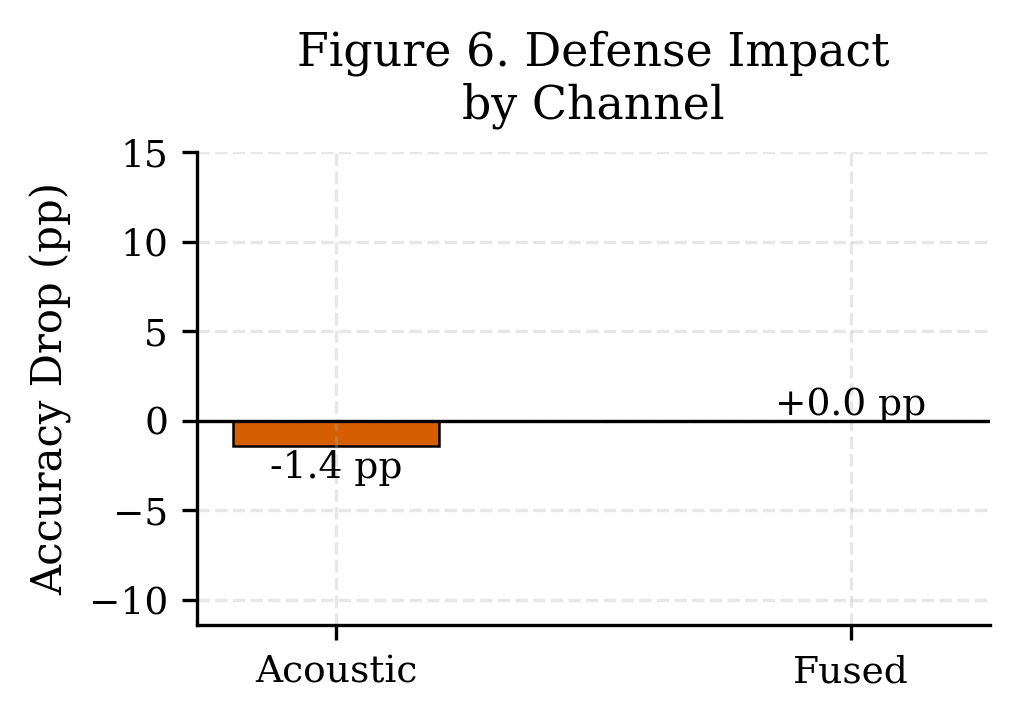

  Fig 6 saved.


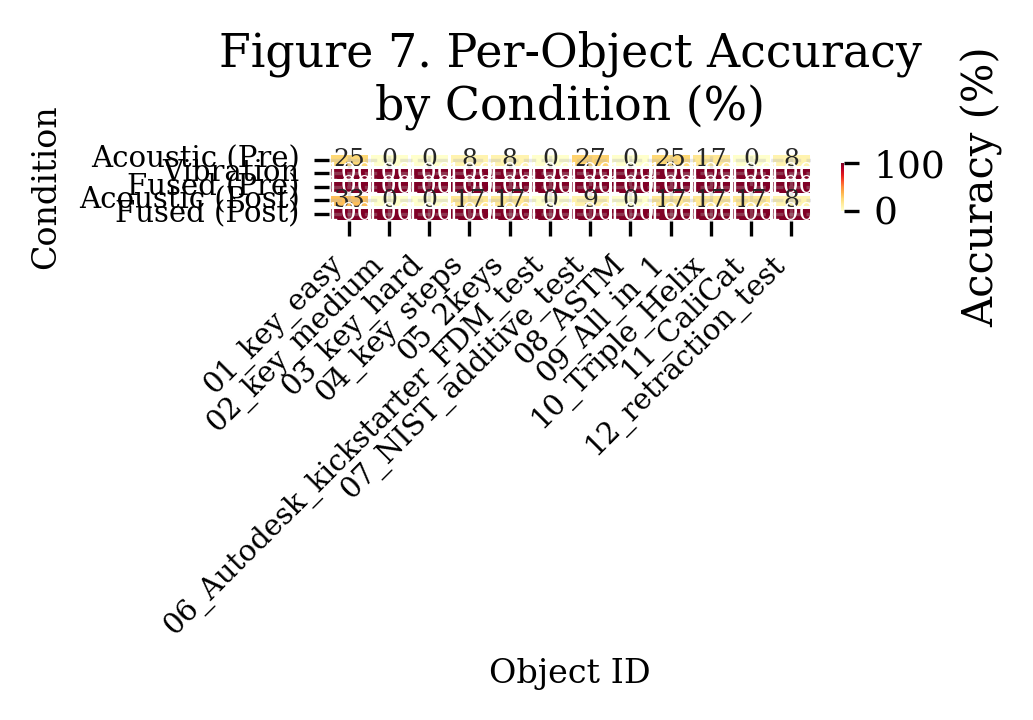

  Fig 7 saved.


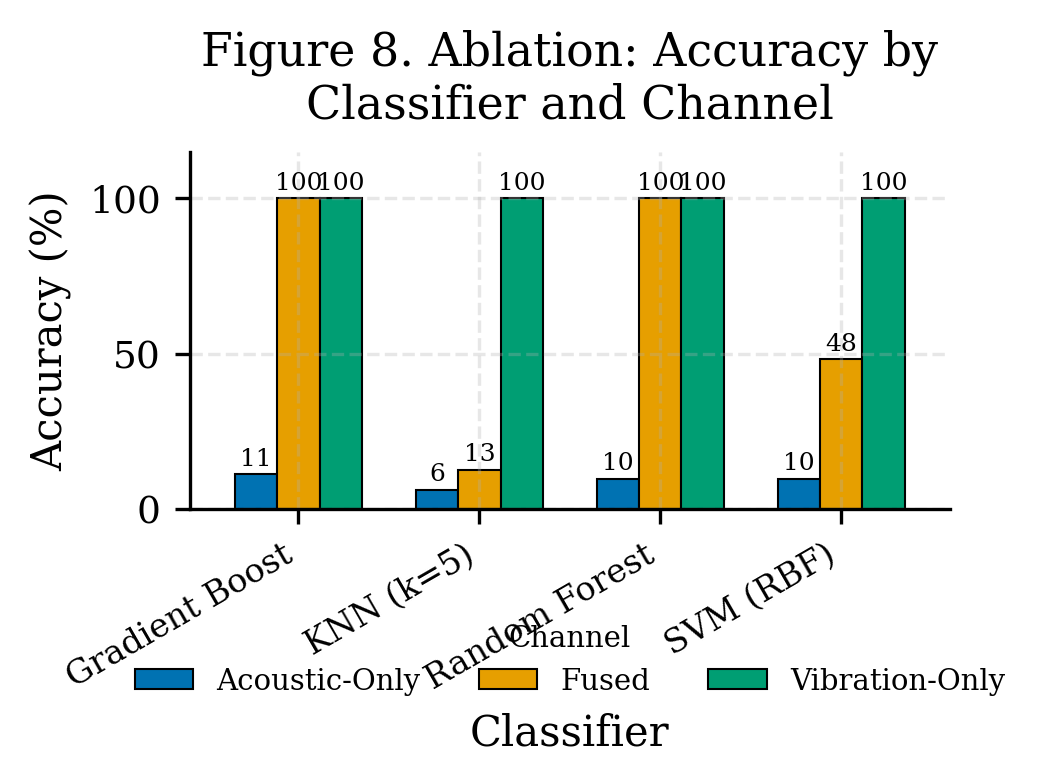

  Fig 8 saved.


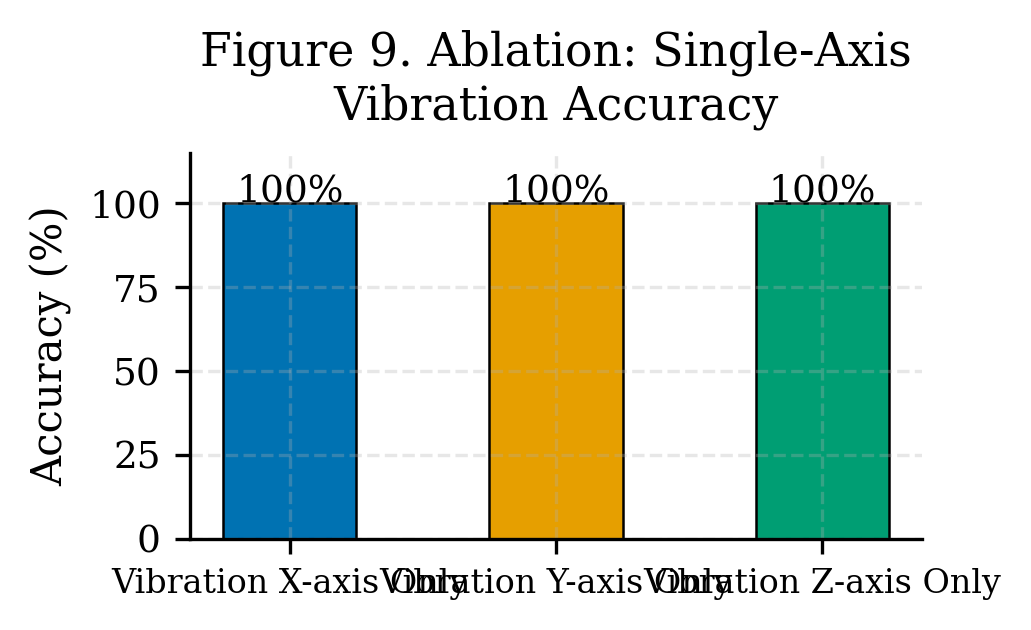

  Fig 9 saved.

All figures saved to /content/drive/MyDrive/3dprinter_sidechannel/results


In [ ]:
# ── Resave all figures as single-column vertical format (3.5" wide) ────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

print('Regenerating all figures in single-column format...')

# ── Figure 1: PCA discriminability ───────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(COL1, 7.5))
titles = ['(a) Acoustic', '(b) Vibration', '(c) Fused']
pcas   = [pca_a, pca_v, pca_f]
cmap   = plt.get_cmap('tab10')
colors = [cmap(i / max(n_cls-1, 1)) for i in range(n_cls)]

for ax, pca, title in zip(axes, pcas, titles):
    for cls_idx, cls_name in enumerate(le.classes_):
        mask = y_enc == cls_idx
        ax.scatter(pca[mask, 0], pca[mask, 1],
                   c=[colors[cls_idx]], label=cls_name,
                   s=18, alpha=0.75, edgecolors='none')
    ax.set_title(title)
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=7)
fig.suptitle('Figure 1. Pre-Attack Baseline: PCA Signal\nDiscriminability by Channel Type',
             fontsize=10, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig1_pca_col1.pdf', bbox_inches='tight')
plt.show()
print('  Fig 1 saved.')


# ── Figure 2: Accuracy by condition ──────────────────────────────────────────
conditions = [
    'Acoustic-Only\n(Pre-Defense)',
    'Vibration-Only',
    'Fused\n(Pre-Defense)',
    'Acoustic-Only\n(Post-Defense)',
    'Fused\n(Post-Defense)'
]
accuracies = [
    res_audio['Accuracy'],
    res_vibr['Accuracy'],
    res_fused['Accuracy'],
    res_audio_d['Accuracy'],
    res_fused_d['Accuracy']
]
phase_colors = [PALETTE[0], PALETTE[2], PALETTE[1], PALETTE[3], PALETTE[4]]

fig, ax = plt.subplots(figsize=(COL1, 3.5))
bars = ax.bar(conditions, accuracies, color=phase_colors,
              edgecolor='black', linewidth=0.6, width=0.6)
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=7)
ax.axhline(ATTACK_THRESHOLD, color='red', linestyle='--',
           linewidth=1, label=f'Attack threshold ({ATTACK_THRESHOLD}%)')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 120)
ax.set_title('Figure 2. Classification Accuracy\nby Experimental Condition', pad=8)
ax.legend(loc='upper right', fontsize=7, frameon=True)
plt.xticks(fontsize=7)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig2_accuracy_col1.pdf', bbox_inches='tight')
plt.show()
print('  Fig 2 saved.')


# ── Figure 3: Robustness profile ──────────────────────────────────────────────
metrics = ['Accuracy', 'F1 (macro)', 'Precision', 'Recall']
cond_plot = {
    'Acoustic (Pre)':  res_audio,
    'Vibration':       res_vibr,
    'Fused (Pre)':     res_fused,
    'Acoustic (Post)': res_audio_d,
    'Fused (Post)':    res_fused_d,
}
x     = np.arange(len(metrics))
n     = len(cond_plot)
width = 0.15

fig, ax = plt.subplots(figsize=(COL1, 3.2))
for i, (cond_name, res) in enumerate(cond_plot.items()):
    vals   = [res[m] for m in metrics]
    offset = (i - n/2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=cond_name,
           color=PALETTE[i % len(PALETTE)],
           edgecolor='black', linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=8)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 125)
ax.set_title('Figure 3. Robustness Profile:\nAll Metrics by Condition', pad=8)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=2, frameon=False, fontsize=7)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig3_robustness_col1.pdf', bbox_inches='tight')
plt.show()
print('  Fig 3 saved.')


# ── Figure 4: Confusion matrix — fused post-defense ──────────────────────────
cm      = confusion_matrix(y_enc, res_fused_d['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(COL1, 2.8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 6})
ax.set_xlabel('Predicted Object', fontsize=8)
ax.set_ylabel('True Object', fontsize=8)
ax.set_title('Figure 4. Confusion Matrix:\nFused Attack (Post-Defense)', pad=8)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig4_confusion_col1.pdf', bbox_inches='tight')
plt.show()
print('  Fig 4 saved.')


# ── Figure 5: Spectrogram before vs. after AMNC ───────────────────────────────
sample_audio = catalog.iloc[0]['audio_path']
try:
    y_raw, sr = librosa.load(sample_audio, sr=16000, mono=True, duration=10)
    y_def     = simulate_amnc(y_raw, sr)

    fig, axes = plt.subplots(2, 1, figsize=(COL1, 4.0), sharey=True)
    for ax, sig, ttl in zip(axes,
                             [y_raw, y_def],
                             ['(a) Pre-Defense (Raw Acoustic)',
                              '(b) Post-Defense (AMNC Applied)']):
        D   = librosa.amplitude_to_db(np.abs(librosa.stft(sig)), ref=np.max)
        img = librosa.display.specshow(D, sr=sr, x_axis='time',
                                        y_axis='hz', ax=ax, cmap='magma')
        ax.set_title(ttl, fontsize=9)
        ax.set_ylim(0, 2000)
        ax.set_xlabel('Time (s)', fontsize=8)
    axes[0].set_ylabel('Frequency (Hz)', fontsize=8)
    axes[1].set_ylabel('Frequency (Hz)', fontsize=8)
    fig.colorbar(img, ax=axes, format='%+2.0f dB',
                 shrink=0.6, label='dB')
    fig.suptitle('Figure 5. Spectrogram: Effect of AMNC\non Acoustic Side-Channel Signal',
                 fontsize=10)
    plt.tight_layout()
    fig.savefig(f'{OUTPUT_DIR}/fig5_spectrogram_col1.pdf', bbox_inches='tight')
    plt.show()
    print('  Fig 5 saved.')
except Exception as e:
    print(f'  Fig 5 skipped: {e}')


# ── Figure 6: Defense impact delta ───────────────────────────────────────────
channels = ['Acoustic', 'Fused']
deltas   = [
    res_audio['Accuracy']  - res_audio_d['Accuracy'],
    res_fused['Accuracy']  - res_fused_d['Accuracy'],
]
bar_colors = [PALETTE[0] if d >= 0 else PALETTE[3] for d in deltas]

fig, ax = plt.subplots(figsize=(COL1, 2.5))
bars = ax.bar(channels, deltas, color=bar_colors,
              edgecolor='black', linewidth=0.6, width=0.4)
for bar, val in zip(bars, deltas):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.8
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.1f} pp', ha='center', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Accuracy Drop (pp)')
ax.set_title('Figure 6. Defense Impact\nby Channel', pad=8)
ax.set_ylim(min(deltas) - 10, max(deltas) + 15)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig6_defense_col1.pdf', bbox_inches='tight')
plt.show()
print('  Fig 6 saved.')


# ── Figure 7: Per-object accuracy heatmap ────────────────────────────────────
def per_object_accuracy(y_true, y_pred, classes):
    return {cls: accuracy_score(y_true[y_true==idx], y_pred[y_true==idx]) * 100
            for idx, cls in enumerate(classes)
            if (y_true==idx).sum() > 0}

obj_accs = pd.DataFrame({
    'Acoustic (Pre)':  per_object_accuracy(y_enc, res_audio['y_pred'],   le.classes_),
    'Vibration':       per_object_accuracy(y_enc, res_vibr['y_pred'],    le.classes_),
    'Fused (Pre)':     per_object_accuracy(y_enc, res_fused['y_pred'],   le.classes_),
    'Acoustic (Post)': per_object_accuracy(y_enc, res_audio_d['y_pred'], le.classes_),
    'Fused (Post)':    per_object_accuracy(y_enc, res_fused_d['y_pred'], le.classes_),
}).T

fig, ax = plt.subplots(figsize=(COL1, 2.5))
sns.heatmap(obj_accs, annot=True, fmt='.0f', cmap='YlOrRd',
            vmin=0, vmax=100, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.7},
            annot_kws={'size': 6})
ax.set_xlabel('Object ID', fontsize=8)
ax.set_ylabel('Condition', fontsize=8)
ax.set_title('Figure 7. Per-Object Accuracy\nby Condition (%)', pad=8)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig7_perobject_col1.pdf', bbox_inches='tight')
plt.show()
print('  Fig 7 saved.')


# ── Figure 8: Ablation — classifier comparison ───────────────────────────────
abl_pivot = ablation_df[ablation_df['Channel'].isin(
    ['Acoustic-Only', 'Vibration-Only', 'Fused'])].pivot(
    index='Classifier', columns='Channel', values='Accuracy')

fig, ax = plt.subplots(figsize=(COL1, 2.8))
abl_pivot.plot(kind='bar', ax=ax,
               color=PALETTE[:3], edgecolor='black',
               linewidth=0.5, width=0.7)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_title('Figure 8. Ablation: Accuracy by\nClassifier and Channel', pad=8)
ax.legend(title='Channel', fontsize=7, title_fontsize=7,
          loc='upper center', bbox_to_anchor=(0.5, -0.25),
          ncol=3, frameon=False)
plt.xticks(rotation=30, ha='right', fontsize=8)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=6, padding=1)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig8_ablation_classifiers_col1.pdf', bbox_inches='tight')
plt.show()
print('  Fig 8 saved.')


# ── Figure 9: Ablation — vibration axis breakdown ────────────────────────────
axis_rows = ablation_df[ablation_df['Channel'].str.contains('axis')]

fig, ax = plt.subplots(figsize=(COL1, 2.2))
ax.bar(axis_rows['Channel'], axis_rows['Accuracy'],
       color=PALETTE[:3], edgecolor='black', linewidth=0.6, width=0.5)
for i, (_, row) in enumerate(axis_rows.iterrows()):
    ax.text(i, row['Accuracy'] + 0.5, f"{row['Accuracy']:.0f}%",
            ha='center', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_title('Figure 9. Ablation: Single-Axis\nVibration Accuracy', pad=8)
plt.xticks(fontsize=8)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig9_ablation_axes_col1.pdf', bbox_inches='tight')
plt.show()
print('  Fig 9 saved.')


print(f'\nAll figures saved to {OUTPUT_DIR}')

In [ ]:
from scipy.stats import binom
from statsmodels.stats.proportion import proportion_confint

n = len(records)

print('='*55)
print('Statistical Significance Summary')
print('='*55)

for label, res in [
    ('Acoustic-Only',  res_audio),
    ('Vibration-Only', res_vibr),
    ('Fused (Pre)',    res_fused),
    ('Acoustic (Post)',res_audio_d),
    ('Fused (Post)',   res_fused_d),
]:
    k = int(round(res['Accuracy'] / 100 * n))

    # Wilson interval — handles k=0 and k=n without collapsing
    ci_low, ci_high = proportion_confint(k, n, alpha=0.05, method='wilson')

    # One-sided binomial test: is accuracy > random chance (1/n_cls)?
    random_baseline = 1.0 / n_cls
    p_value = binom.sf(k-1, n, random_baseline)

    print(f'\n{label}')
    print(f'  Accuracy : {res["Accuracy"]:.2f}%')
    print(f'  95% CI   : [{ci_low*100:.2f}%, {ci_high*100:.2f}%] (Wilson)')
    print(f'  Baseline : {random_baseline*100:.2f}% (random chance, 1/{n_cls} classes)')
    print(f'  p-value  : {p_value:.2e} (H0: accuracy <= random baseline)')
    print(f'  Significant (p<0.05): {p_value < 0.05}')

print('='*55)

Statistical Significance Summary

Acoustic-Only
  Accuracy : 9.79%
  95% CI   : [5.92%, 15.76%] (Wilson)
  Baseline : 8.33% (random chance, 1/12 classes)
  p-value  : 3.05e-01 (H0: accuracy <= random baseline)
  Significant (p<0.05): False

Vibration-Only
  Accuracy : 100.00%
  95% CI   : [97.38%, 100.00%] (Wilson)
  Baseline : 8.33% (random chance, 1/12 classes)
  p-value  : 4.75e-155 (H0: accuracy <= random baseline)
  Significant (p<0.05): True

Fused (Pre)
  Accuracy : 100.00%
  95% CI   : [97.38%, 100.00%] (Wilson)
  Baseline : 8.33% (random chance, 1/12 classes)
  p-value  : 4.75e-155 (H0: accuracy <= random baseline)
  Significant (p<0.05): True

Acoustic (Post)
  Accuracy : 11.19%
  95% CI   : [7.01%, 17.40%] (Wilson)
  Baseline : 8.33% (random chance, 1/12 classes)
  p-value  : 1.40e-01 (H0: accuracy <= random baseline)
  Significant (p<0.05): False

Fused (Post)
  Accuracy : 100.00%
  95% CI   : [97.38%, 100.00%] (Wilson)
  Baseline : 8.33% (random chance, 1/12 classes)
  p-v

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

# Acoustic vs vibration predictions
correct_audio = (res_audio['y_pred'] == y_enc)
correct_vibr  = (res_vibr['y_pred']  == y_enc)
table = np.array([
    [(correct_audio & correct_vibr).sum(),  (~correct_audio & correct_vibr).sum()],
    [(correct_audio & ~correct_vibr).sum(), (~correct_audio & ~correct_vibr).sum()]
])
result = mcnemar(table, exact=True)
print(f'McNemar test: p = {result.pvalue:.4f}')

McNemar test: p = 0.0000


In [ ]:
# ── Strip titles from PDFs and convert to 300 DPI PNG ─────────────────────────
!apt-get install -q poppler-utils
!pip install -q pymupdf

import os
import subprocess
import fitz  # pymupdf

FIG_DIR = f'{OUTPUT_DIR}'
PNG_DIR = f'{OUTPUT_DIR}/png'
os.makedirs(PNG_DIR, exist_ok=True)

CLEAN_DIR = f'{OUTPUT_DIR}/clean_pdf'
os.makedirs(CLEAN_DIR, exist_ok=True)

for f in sorted(os.listdir(FIG_DIR)):
    if not (f.endswith('.pdf') and f.startswith('fig')):
        continue

    pdf_path   = os.path.join(FIG_DIR, f)
    clean_path = os.path.join(CLEAN_DIR, f)
    png_base   = os.path.join(PNG_DIR, f.replace('.pdf', ''))

    # Open PDF and remove all text blocks that look like figure titles
    doc = fitz.open(pdf_path)
    for page in doc:
        blocks = page.get_text('blocks')
        for block in blocks:
            x0, y0, x1, y1, text, *_ = block
            text = text.strip()
            # Remove if it looks like a title (short, bold, near top of page)
            if (y0 < 80 and len(text) < 120 and '\n' not in text.strip()):
                page.add_redact_annot((x0, y0, x1, y1), fill=(1,1,1))
        page.apply_redactions()
    doc.save(clean_path)
    doc.close()

    # Convert cleaned PDF to PNG at 300 DPI
    subprocess.run([
        'pdftoppm', '-r', '300', '-png', '-singlefile',
        clean_path, png_base
    ], check=True)
    print(f'Done: {f}')

print(f'\nAll PNGs saved to {PNG_DIR}')
print(sorted(os.listdir(PNG_DIR)))

Reading package lists...
Building dependency tree...
Reading state information...
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 38.2 MB/s eta 0:00:00
Done: fig1_pca_col1.pdf
Done: fig1_pca_discriminability.pdf
Done: fig2_accuracy_by_condition.pdf
Done: fig2_accuracy_col1.pdf
Done: fig3_robustness_col1.pdf
Done: fig3_robustness_profile.pdf
Done: fig4_confusion_col1.pdf
Done: fig4_confusion_fused_postdefense.pdf
Done: fig5_spectrogram_amnc.pdf
Done: fig5_spectrogram_col1.pdf
Done: fig6_defense_col1.pdf
Done: fig6_defense_impact.pdf
Done: fig7_per_object_heatmap.pdf
Done: fig7_perobject_col1.pdf
Done: fig8_ablation_classifiers_col1.pdf
Done: fig9_ablation_axes_col1.pdf

All PNGs saved to /content/drive/MyDrive/3dprinter_sidechannel/results/png
['fig1_pca_col1.png', 'fig1_pca_discriminability.png', 'fig2_accuracy_by_condition.png', 'fig2_accuracy_col1

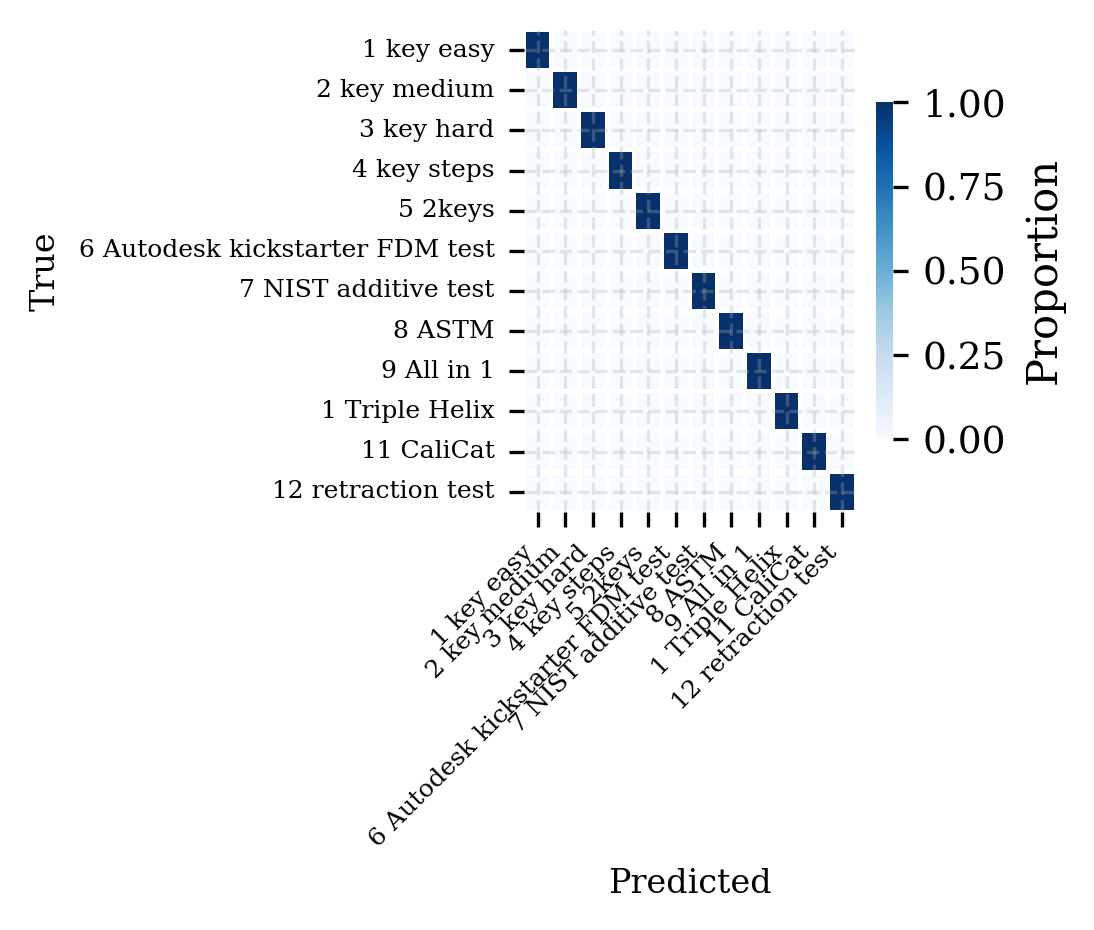

Done.


In [34]:
# ── Regenerate Figure 4: Confusion Matrix — no annotations ───────────────────
cm      = confusion_matrix(y_enc, res_fused_d['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

short_labels = [c.replace('0','').replace('_',' ').strip()
                for c in le.classes_]

fig, ax = plt.subplots(figsize=(3.5, 3.2))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels,
            linewidths=0.5, linecolor='white',
            vmin=0, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.7, 'label': 'Proportion'})
ax.set_xlabel('Predicted', fontsize=8)
ax.set_ylabel('True', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()

fig.savefig(f'{OUTPUT_DIR}/fig4_confusion_col1.pdf', bbox_inches='tight', dpi=300)

import subprocess
png_out = f'{PNG_DIR}/fig4_confusion_col1'
subprocess.run(['pdftoppm', '-r', '300', '-png', '-singlefile',
                f'{OUTPUT_DIR}/fig4_confusion_col1.pdf',
                png_out], check=True)
plt.show()
print('Done.')

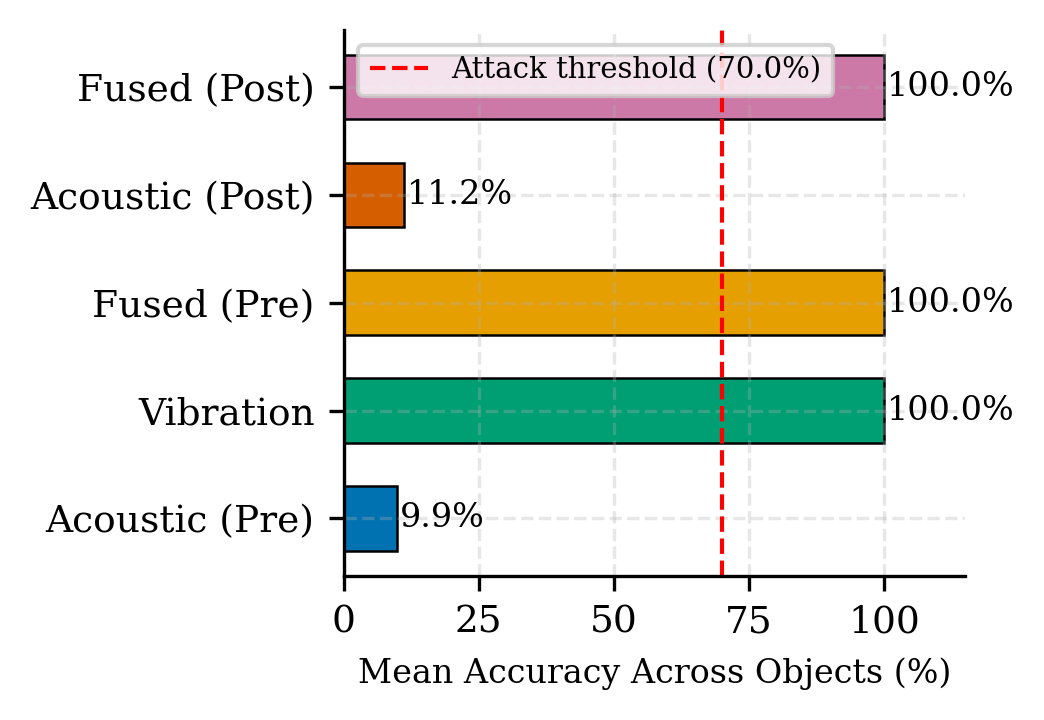

Done.


In [37]:
# ── Regenerate Figure 7: Per-object accuracy — horizontal bars ────────────────
def per_obj(y_true, y_pred, classes):
    return {cls: accuracy_score(y_true[y_true==i], y_pred[y_true==i]) * 100
            for i, cls in enumerate(classes) if (y_true==i).sum() > 0}

conditions = ['Acoustic (Pre)', 'Vibration', 'Fused (Pre)',
              'Acoustic (Post)', 'Fused (Post)']

mean_accs = [
    np.mean(list(per_obj(y_enc, res_audio['y_pred'],   le.classes_).values())),
    np.mean(list(per_obj(y_enc, res_vibr['y_pred'],    le.classes_).values())),
    np.mean(list(per_obj(y_enc, res_fused['y_pred'],   le.classes_).values())),
    np.mean(list(per_obj(y_enc, res_audio_d['y_pred'], le.classes_).values())),
    np.mean(list(per_obj(y_enc, res_fused_d['y_pred'], le.classes_).values())),
]

colors = [PALETTE[0], PALETTE[2], PALETTE[1], PALETTE[3], PALETTE[4]]

fig, ax = plt.subplots(figsize=(3.5, 2.5))
bars = ax.barh(conditions, mean_accs, color=colors,
               edgecolor='black', linewidth=0.6, height=0.6)
for bar, val in zip(bars, mean_accs):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
ax.set_xlabel('Mean Accuracy Across Objects (%)', fontsize=8)
ax.set_xlim(0, 115)
ax.axvline(ATTACK_THRESHOLD, color='red', linestyle='--',
           linewidth=1, label=f'Attack threshold ({ATTACK_THRESHOLD}%)')
ax.legend(fontsize=7, frameon=True)
plt.tight_layout()

fig.savefig(f'{OUTPUT_DIR}/fig7_perobject_col1.pdf', bbox_inches='tight', dpi=300)

png_out = f'{PNG_DIR}/fig7_perobject_col1'
subprocess.run(['pdftoppm', '-r', '300', '-png', '-singlefile',
                f'{OUTPUT_DIR}/fig7_perobject_col1.pdf',
                png_out], check=True)
plt.show()
print('Done.')

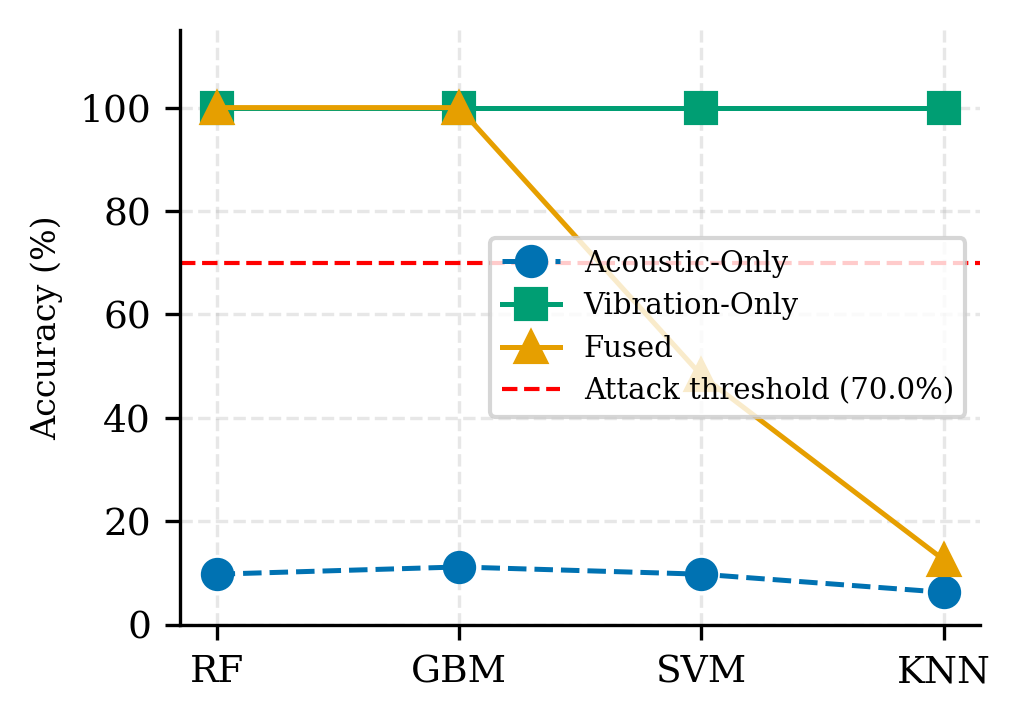

Done.


In [38]:
# ── Regenerate Figure 8: Ablation classifiers — dot plot ─────────────────────
import matplotlib.lines as mlines

classifiers = ['Random Forest', 'Gradient Boost', 'SVM (RBF)', 'KNN (k=5)']
acoustic  = [9.79,  11.19,  9.79,  6.29]
vibration = [100.0, 100.0, 100.0, 100.0]
fused     = [100.0, 100.0,  48.25, 12.59]

x = np.arange(len(classifiers))

fig, ax = plt.subplots(figsize=(3.5, 2.5))

ax.plot(x, acoustic,  'o--', color=PALETTE[0], markersize=7,
        linewidth=1.2, label='Acoustic-Only')
ax.plot(x, vibration, 's-',  color=PALETTE[2], markersize=7,
        linewidth=1.2, label='Vibration-Only')
ax.plot(x, fused,     '^-',  color=PALETTE[1], markersize=7,
        linewidth=1.2, label='Fused')

ax.axhline(ATTACK_THRESHOLD, color='red', linestyle='--',
           linewidth=1, label=f'Attack threshold ({ATTACK_THRESHOLD}%)')

ax.set_xticks(x)
ax.set_xticklabels(['RF', 'GBM', 'SVM', 'KNN'], fontsize=9)
ax.set_ylabel('Accuracy (%)', fontsize=8)
ax.set_ylim(0, 115)
ax.legend(fontsize=7, frameon=True, loc='center right')
plt.tight_layout()

fig.savefig(f'{OUTPUT_DIR}/fig8_ablation_classifiers_col1.pdf',
            bbox_inches='tight', dpi=300)

png_out = f'{PNG_DIR}/fig8_ablation_classifiers_col1'
subprocess.run(['pdftoppm', '-r', '300', '-png', '-singlefile',
                f'{OUTPUT_DIR}/fig8_ablation_classifiers_col1.pdf',
                png_out], check=True)
plt.show()
print('Done.')